# FNO Model 3 (Omega + 3 channels, 4 total) 16x16x16 train/val + 64x64x64 test (test data to be generated)
# FNO model of random in time distribution. Train-test-val on every dataset
# Good train-test-val losses

In [1]:
# =========================
# Imports and experiment configuration (3D grid training)
# =========================
import glob
import random
import re
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

from neuralop.models import FNO
from neuralop.losses import LpLoss
from neuralop.utils import count_model_params

# Central config: edit here only.
CFG = {
    # Random seed for reproducibility across numpy/torch/data split steps.
    'seed': 42,
    # Switch for quick preliminary runs before full-scale training.
    'fast_sanity_mode': False,

    # Optional dataset root used for relative paths.
    # This repo's datasets live one level above the repo root on this machine.
    'data_root': '.',

    # Pooled low-resolution folders used for a mixed frame-level split.
    'split_dirs': [
        'train/pair_1_fno_32/',
        'train/pair_2_fno_32/',
        'train/pair_3_fno_32/',
        'train/pair_4_fno_32/',
        'train/pair_5_fno_32/',
    ],
    # Frame-level split within the pooled 16^3 dataset.
    'split_strategy': 'random_frames',
    'train_frac': 0.70,
    'val_frac': 0.15,
    'test_frac': 0.15,
    # Super-resolution-specific test dirs are disabled for now.
    'test_dirs': [],
    'test_sr_dirs': [],

    # Skip initial frames in train/val/test to avoid transient startup (set to 0 to disable).
    'min_frame_trainval': 10,
    'min_frame_test': 10,
    'min_frame_sr': 10,

    # 3D resolution checks.
    'train_expected_res': 32,
    'test_expected_res': 32,
    # Optional expected resolution for super-resolution test set.
    'test_sr_expected_res': 'auto',

    # If True, training still runs even when no test dirs are provided.
    'allow_missing_test_dirs': True,

    # Optional file caps for quick sanity runs.
    'max_train_files': 256,
    'max_val_files': 64,
    'max_test_files': 64,
    'max_test_sr_files': None,

    # Spatial subsampling stride in dataset loader.
    'train_grid_stride': 1,
    'val_grid_stride': 1,
    'test_grid_stride': 1,

    # Feature scaling controls (computed from TRAIN split only).
    'normalize_inputs': True,
    'normalize_targets': True,
    'strict_normalization': True,
    'norm_eps': 1e-6,
    'norm_max_files': 192,

    # DataLoader tuning (set num_workers>0 for faster IO if supported).
    'num_workers': 0,
    'pin_memory': True,
    'prefetch_factor': 2,

    # Training loop diagnostics/shortcuts.
    'log_every_batches': 10,
    'max_batches_per_epoch': None,  # set to int for quick sanity runs

    # Optimization.
    'batch_size': 2,
    'epochs': 120,
    'lr': 1e-3,
    'weight_decay': 1e-4,

    # FNO architecture.
    'n_modes': (10, 10, 10),
    'hidden_channels': 64,
    'projection_channel_ratio': 2,

    # Evaluate every N epochs.
    'eval_every': 1,

    # Strict output checks for model inference.
    'strict_output_shape': True,

    # Use best validation checkpoint for all plots/diagnostics.
    'use_best_checkpoint_for_reports': True,

    # Quick experiment safeguards.
    'min_subset_size': 8,

    # Variant-specific fields.
    'input_channels': 4,
    'input_key': 'input_grid_omega4',
    'file_tag': 'fno_sr_randomdist_3d',
}


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG['seed'])
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NON_BLOCKING = DEVICE == 'cuda'
print('Python executable:', sys.executable)
print('Torch version:', torch.__version__)
print('Torch CUDA build:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
if DEVICE == 'cuda':
    print('Device:', DEVICE, '| GPU:', torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
else:
    print('Device:', DEVICE)
    print('[warn] CUDA is not available in this notebook kernel. If gpu_test.py succeeds in fno-env, switch Jupyter to that environment before training.')
print('Variant:', CFG['input_key'], 'channels=', CFG['input_channels'])
print('Split dirs:', CFG['split_dirs'])
print('Split strategy:', CFG['split_strategy'])
print('Split fractions train/val/test:', CFG['train_frac'], CFG['val_frac'], CFG['test_frac'])
print('Fast sanity mode:', CFG['fast_sanity_mode'])
print('Allow missing test dirs:', CFG['allow_missing_test_dirs'])
print('File caps train/val/test/test_sr:', CFG['max_train_files'], CFG['max_val_files'], CFG['max_test_files'], CFG['max_test_sr_files'])
print('Grid stride train/val/test:', CFG['train_grid_stride'], CFG['val_grid_stride'], CFG['test_grid_stride'])
print('Min frames train/val/test/sr:', CFG['min_frame_trainval'], CFG['min_frame_test'], CFG['min_frame_sr'])
print('Normalize inputs/targets:', CFG['normalize_inputs'], CFG['normalize_targets'])

# Apply fast sanity settings (overrides) if enabled.
if CFG.get('fast_sanity_mode'):
    print('[info] FAST_SANITY mode enabled: applying lightweight settings')
    CFG['epochs'] = min(int(CFG.get('epochs', 1)), 5)
    CFG['eval_every'] = max(1, int(CFG.get('eval_every', 1)))
    CFG['max_train_files'] = min(int(CFG.get('max_train_files', 64) or 64), 64)
    CFG['max_val_files'] = min(int(CFG.get('max_val_files', 16) or 16), 16)
    CFG['max_test_files'] = min(int(CFG.get('max_test_files', 16) or 16), 16)
    CFG['max_test_sr_files'] = min(int(CFG.get('max_test_sr_files', 16) or 16), 16)
    CFG['max_batches_per_epoch'] = int(CFG.get('max_batches_per_epoch') or 5)
    CFG['log_every_batches'] = int(CFG.get('log_every_batches') or 5)
    # Disable SR evaluation during training in fast mode (can re-enable for post-eval).
    CFG['test_sr_dirs'] = []
    # Use a smaller scheduler length for quick checks.
    CFG['epochs'] = max(1, CFG['epochs'])

    print('[info] FAST_SANITY settings applied:', {
        'epochs': CFG['epochs'],
        'eval_every': CFG['eval_every'],
        'max_train_files': CFG['max_train_files'],
        'max_val_files': CFG['max_val_files'],
        'max_test_files': CFG['max_test_files'],
        'max_test_sr_files': CFG['max_test_sr_files'],
        'max_batches_per_epoch': CFG['max_batches_per_epoch'],
        'log_every_batches': CFG['log_every_batches'],
        'test_sr_dirs': CFG['test_sr_dirs'],
    })


Python executable: c:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\fno-env\Scripts\python.exe
Torch version: 2.6.0+cu124
Torch CUDA build: 12.4
CUDA available: True
Device: cuda | GPU: NVIDIA RTX 4000 Ada Generation
Variant: input_grid_omega4 channels= 4
Split dirs: ['train/pair_1_fno_32/', 'train/pair_2_fno_32/', 'train/pair_3_fno_32/', 'train/pair_4_fno_32/', 'train/pair_5_fno_32/']
Split strategy: random_frames
Split fractions train/val/test: 0.7 0.15 0.15
Fast sanity mode: False
Allow missing test dirs: True
File caps train/val/test/test_sr: 256 64 64 None
Grid stride train/val/test: 1 1 1
Min frames train/val/test/sr: 10 10 10
Normalize inputs/targets: True True


In [2]:
# =========================
# Data setup (3D train/val + optional 3D test) + normalization
# =========================
cwd = Path.cwd().resolve()
if (cwd / '.git').exists():
    REPO_ROOT = cwd
elif (cwd.parent / '.git').exists():
    REPO_ROOT = cwd.parent
else:
    # Fallback for notebook servers launched outside repo root.
    REPO_ROOT = cwd

data_root_cfg = CFG.get('data_root')
if data_root_cfg in (None, '', '.'):
    DATA_ROOT = REPO_ROOT
else:
    data_root_path = Path(data_root_cfg).expanduser()
    if data_root_path.is_absolute():
        DATA_ROOT = data_root_path.resolve()
    else:
        # Resolve relative data_root from repo root, not notebook cwd.
        DATA_ROOT = (REPO_ROOT / data_root_path).resolve()

print('Detected REPO_ROOT:', REPO_ROOT)
print('DATA_ROOT:', DATA_ROOT)

RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Results directory:', RESULTS_DIR)

ALLOW_MISSING_TEST = bool(CFG.get('allow_missing_test_dirs')) or bool(CFG.get('fast_sanity_mode'))


def save_fig(fig, filename, dpi=300):
    out = RESULTS_DIR / f"{CFG['file_tag']}_{filename}"
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f'[saved] {out}')


def resolve_dirs(path_list, must_exist=True, base_root=DATA_ROOT):
    dirs = []
    for d in path_list:
        p = Path(d).expanduser()
        if p.is_absolute():
            candidates = [p.resolve()]
        else:
            candidates = [(base_root / p).resolve()]
            # Fallback to repo-root relative path to avoid cwd-dependent failures.
            repo_candidate = (REPO_ROOT / p).resolve()
            if repo_candidate not in candidates:
                candidates.append(repo_candidate)

        found = next((c for c in candidates if c.is_dir()), None)
        if found is not None:
            dirs.append(found)
            continue

        if must_exist:
            tried = ' | '.join(str(c) for c in candidates)
            raise FileNotFoundError(f'Missing directory: {p}. Tried: {tried}')
        else:
            print(f'[warn] directory missing, skipping: {candidates[0]}')
    return dirs


SPLIT_DIRS = resolve_dirs(CFG['split_dirs'], must_exist=True)
TEST_DIRS = resolve_dirs(CFG['test_dirs'], must_exist=not ALLOW_MISSING_TEST)
TEST_SR_DIRS = resolve_dirs(CFG['test_sr_dirs'], must_exist=False)

if not ALLOW_MISSING_TEST and len(TEST_DIRS) == 0 and len(TEST_SR_DIRS) == 0:
    raise RuntimeError('No test/test_sr dirs provided and allow_missing_test_dirs=False')


FRAME_RE = re.compile(r'frame_(\d+)', re.IGNORECASE)


def parse_frame_id(path_like):
    name = Path(path_like).name
    m = FRAME_RE.search(name)
    if not m:
        raise ValueError(f'Cannot parse frame id from filename: {name}')
    return int(m.group(1))


def list_frame_files(sim_dir, expect_gridded=True):
    grid_files = sorted(
        glob.glob(str(sim_dir / 'frame_*_grid.npz')),
        key=parse_frame_id,
    )
    if grid_files:
        return grid_files

    raw_files = sorted(
        glob.glob(str(sim_dir / 'frame_*.npz')),
        key=parse_frame_id,
    )

    if raw_files and expect_gridded:
        sample = np.load(raw_files[0])
        raise RuntimeError(
            f"Directory {sim_dir} has raw frame_*.npz ({len(raw_files)} files) but no frame_*_grid.npz. "
            f"Sample keys: {list(sample.files)}. "
            "This notebook expects gridded data with U_grid/input_grid_* keys. "
            "Run dataset_gen/autodomain_particle_grid.py and point CFG train/test dirs to pair_*_fno* folders."
        )

    return raw_files


def gridded_file_is_valid(file_path, input_key, expected_channels):
    if Path(file_path).stat().st_size == 0:
        return False, 'empty_file'

    try:
        d = np.load(file_path)
    except Exception as exc:
        return False, f'load_error: {exc}'

    if input_key not in d:
        return False, f"missing_input_key:{input_key}"
    if 'U_grid' not in d:
        return False, 'missing_output_key:U_grid'

    x = np.asarray(d[input_key], dtype=np.float32)
    y = np.asarray(d['U_grid'], dtype=np.float32)

    if x.ndim != 4 or y.ndim != 4:
        return False, f'bad_rank:x{tuple(x.shape)}_y{tuple(y.shape)}'
    if x.shape[0] != expected_channels:
        return False, f'bad_input_channels:{x.shape[0]}!=exp{expected_channels}'
    if y.shape[0] != 3:
        return False, f'bad_output_channels:{y.shape[0]}'
    if x.shape[-3:] != y.shape[-3:]:
        return False, f'res_mismatch:x{tuple(x.shape[-3:])}_y{tuple(y.shape[-3:])}'

    if not np.isfinite(x).all():
        return False, 'non_finite_input'
    if not np.isfinite(y).all():
        return False, 'non_finite_output'

    return True, 'ok'


def filter_valid_gridded_files(files, input_key, expected_channels, label, max_report=5):
    valid = []
    dropped = []
    for fp in files:
        ok, reason = gridded_file_is_valid(fp, input_key=input_key, expected_channels=expected_channels)
        if ok:
            valid.append(fp)
        else:
            dropped.append((fp, reason))

    if dropped:
        print(f"[warn] {label}: dropped {len(dropped)} invalid files")
        for fp, reason in dropped[:max_report]:
            print(f"    - {Path(fp).name}: {reason}")
        if len(dropped) > max_report:
            print(f"    ... and {len(dropped) - max_report} more")

    return valid


def filter_by_min_frame(files, min_frame, label):
    if min_frame in (None, 0):
        return files
    kept = [f for f in files if parse_frame_id(f) >= min_frame]
    if len(kept) != len(files):
        print(f"[info] {label} frame filter: kept {len(kept)}/{len(files)} with frame >= {min_frame}")
    return kept


def split_train_val_test(files, train_frac=0.7, val_frac=0.15, test_frac=0.15, strategy='random_frames', seed=42):
    files = list(files)
    n = len(files)

    if n == 0:
        return [], [], []
    if n == 1:
        return files, [], []

    total = float(train_frac) + float(val_frac) + float(test_frac)
    if not np.isclose(total, 1.0):
        raise ValueError(f'train/val/test fractions must sum to 1.0, got {total:.6f}')

    if strategy == 'random_frames':
        rng = np.random.default_rng(seed)
        idx = np.arange(n)
        rng.shuffle(idx)
        files = [files[i] for i in idx]
    elif strategy == 'chronological':
        # Keep sorted order (chronological)
        files = sorted(files, key=parse_frame_id)
    else:
        raise ValueError("split_strategy must be 'random_frames' or 'chronological'")

    n_train = max(1, int(round(train_frac * n)))
    n_test = max(1, int(round(test_frac * n)))
    n_train = min(n_train, n - 2)
    n_test = min(n_test, n - n_train - 1)
    n_val = n - n_train - n_test
    if n_val < 1:
        n_val = 1
        if n_train > n_test:
            n_train -= 1
        else:
            n_test -= 1

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]
    return train_files, val_files, test_files


ALL_SPLIT_FILES = []
for d in SPLIT_DIRS:
    files = list_frame_files(d, expect_gridded=True)
    if len(files) == 0:
        print(f"[warn] no frame files found in split dir: {d}")
        continue
    files = filter_valid_gridded_files(
        files,
        input_key=CFG['input_key'],
        expected_channels=CFG['input_channels'],
        label=f"{d.name} (split pool)",
    )
    files = filter_by_min_frame(files, CFG['min_frame_trainval'], f"{d.name} (split pool)")
    ALL_SPLIT_FILES.extend(files)
    print(f"[info] {d.name}: pooled_total={len(files)}")

TRAIN_FILES, VAL_FILES, TEST_FILES = split_train_val_test(
    ALL_SPLIT_FILES,
    train_frac=CFG['train_frac'],
    val_frac=CFG['val_frac'],
    test_frac=CFG['test_frac'],
    strategy=CFG['split_strategy'],
    seed=CFG['seed'],
)
print(f"[info] pooled split -> train={len(TRAIN_FILES)}, val={len(VAL_FILES)}, test={len(TEST_FILES)}")

if len(TRAIN_FILES) == 0:
    raise RuntimeError(
        "No training files found after directory scan/filtering. "
        "Check CFG['split_dirs'] and ensure valid frame_*_grid.npz files exist."
    )
if len(VAL_FILES) == 0:
    raise RuntimeError(
        "Validation split is empty after filtering. Add more frames or adjust split strategy."
    )

TEST_SR_FILES = []
for d in TEST_SR_DIRS:
    files = list_frame_files(d, expect_gridded=True)
    if len(files) == 0:
        print(f"[warn] no frame files found in test_sr dir: {d}")
        continue

    files = filter_valid_gridded_files(
        files,
        input_key=CFG['input_key'],
        expected_channels=CFG['input_channels'],
        label=f"{d.name} (test_sr)",
    )
    files = filter_by_min_frame(files, CFG['min_frame_sr'], f"{d.name} (test_sr)")
    TEST_SR_FILES.extend(files)

HAS_TEST_SR = len(TEST_SR_FILES) > 0
if not HAS_TEST_SR and len(TEST_SR_DIRS) > 0:
    print('[warn] No valid test_sr files found. SR metrics/plots will be skipped.')

HAS_TEST = len(TEST_FILES) > 0
if not HAS_TEST and len(TEST_DIRS) > 0:
    print('[warn] No valid test files found. Test metrics/plots will be skipped.')

if CFG.get('max_train_files') and len(TRAIN_FILES) > CFG['max_train_files']:
    rng = np.random.default_rng(CFG['seed'] + 1101)
    idx = rng.choice(len(TRAIN_FILES), size=CFG['max_train_files'], replace=False)
    TRAIN_FILES = [TRAIN_FILES[i] for i in sorted(idx.tolist())]
    print(f"[info] train file cap active: using {len(TRAIN_FILES)} files")

if CFG.get('max_val_files') and len(VAL_FILES) > CFG['max_val_files']:
    rng = np.random.default_rng(CFG['seed'] + 1201)
    idx = rng.choice(len(VAL_FILES), size=CFG['max_val_files'], replace=False)
    VAL_FILES = [VAL_FILES[i] for i in sorted(idx.tolist())]
    print(f"[info] val file cap active: using {len(VAL_FILES)} files")

if HAS_TEST and CFG.get('max_test_files') and len(TEST_FILES) > CFG['max_test_files']:
    rng = np.random.default_rng(CFG['seed'] + 1301)
    idx = rng.choice(len(TEST_FILES), size=CFG['max_test_files'], replace=False)
    TEST_FILES = [TEST_FILES[i] for i in sorted(idx.tolist())]
    print(f"[info] test file cap active: using {len(TEST_FILES)} files")

if HAS_TEST_SR and CFG.get('max_test_sr_files') and len(TEST_SR_FILES) > CFG['max_test_sr_files']:
    rng = np.random.default_rng(CFG['seed'] + 1401)
    idx = rng.choice(len(TEST_SR_FILES), size=CFG['max_test_sr_files'], replace=False)
    TEST_SR_FILES = [TEST_SR_FILES[i] for i in sorted(idx.tolist())]
    print(f"[info] test_sr file cap active: using {len(TEST_SR_FILES)} files")

# Re-apply frame filters after any capping or manual list edits.
TRAIN_FILES = filter_by_min_frame(TRAIN_FILES, CFG['min_frame_trainval'], 'TRAIN_FILES (post)')
VAL_FILES = filter_by_min_frame(VAL_FILES, CFG['min_frame_trainval'], 'VAL_FILES (post)')
TEST_FILES = filter_by_min_frame(TEST_FILES, CFG['min_frame_test'], 'TEST_FILES (post)')
TEST_SR_FILES = filter_by_min_frame(TEST_SR_FILES, CFG['min_frame_sr'], 'TEST_SR_FILES (post)')


def summarize_frame_range(files, label):
    if len(files) == 0:
        print(f'[{label}] no files')
        return
    frames = [parse_frame_id(f) for f in files]
    print(f'[{label}] frame range: {min(frames)}..{max(frames)} (n={len(frames)})')

print(f"Train files: {len(TRAIN_FILES)} | Val files: {len(VAL_FILES)} | Test files: {len(TEST_FILES)}")
print(f"Test SR files: {len(TEST_SR_FILES)}")
summarize_frame_range(TRAIN_FILES, 'TRAIN')
summarize_frame_range(VAL_FILES, 'VAL')
if HAS_TEST:
    summarize_frame_range(TEST_FILES, 'TEST')
if HAS_TEST_SR:
    summarize_frame_range(TEST_SR_FILES, 'TEST_SR')


def preview_index_map(files, label, max_items=8):
    print(f"[{label}] index preview (first {min(len(files), max_items)} entries)")
    for i, fp in enumerate(files[:max_items]):
        print(f"  idx={i:03d} frame={parse_frame_id(fp)} file={Path(fp).name}")


preview_index_map(TRAIN_FILES, 'TRAIN')
preview_index_map(VAL_FILES, 'VAL')
if HAS_TEST:
    preview_index_map(TEST_FILES, 'TEST')
if HAS_TEST_SR:
    preview_index_map(TEST_SR_FILES, 'TEST_SR')
if len(CFG.get('test_dirs', [])) > 0 and not HAS_TEST:
    print('[warn] Configured test_dirs but no valid test files were loaded. Any later fallback visuals will come from VAL/TRAIN, which are usually 16^3 in this notebook.')


def load_x(data):
    key = CFG['input_key']
    if key not in data:
        raise KeyError(f"Missing key '{key}'. Available: {data.files}")
    x = np.asarray(data[key], dtype=np.float32)
    return x


def infer_expected_res(file_path):
    d = np.load(file_path)
    x = load_x(d)
    if x.ndim >= 4:
        return int(x.shape[-1])
    return None


def resolve_expected_res(files, expected_res, label):
    if len(files) == 0:
        return expected_res
    actual = infer_expected_res(files[0])
    if expected_res in (None, 'auto'):
        print(f"[info] {label} expected_res auto-set to {actual}")
        return actual
    if actual is not None and actual != expected_res:
        print(f"[warn] {label} expected_res={expected_res} but data shows {actual}; using data value")
        return actual
    return expected_res


def assert_shapes(files, expected_channels, expected_res=None, label='set'):
    if len(files) == 0:
        return

    bad = []
    for f in files:
        d = np.load(f)
        x = load_x(d)
        y = np.asarray(d['U_grid'], dtype=np.float32)

        ok_channels = (x.shape[0] == expected_channels and y.shape[0] == 3)
        ok_rank = (x.ndim == 4 and y.ndim == 4)

        ok_res = True
        if expected_res is not None:
            ok_res = (
                x.shape[-3:] == (expected_res, expected_res, expected_res)
                and y.shape[-3:] == (expected_res, expected_res, expected_res)
            )

        if not (ok_channels and ok_rank and ok_res):
            bad.append((f, tuple(x.shape), tuple(y.shape)))
            if len(bad) >= 5:
                break

    if bad:
        msg = '\n'.join([f"{fp} -> x:{xs}, y:{ys}" for fp, xs, ys in bad])
        raise RuntimeError(f"{label} shape check failed. Examples:\n{msg}")


def assert_no_overlap(a, b):
    inter = set(a).intersection(set(b))
    if inter:
        raise RuntimeError(f"Train/val leakage detected with {len(inter)} overlapping files")


assert_no_overlap(TRAIN_FILES, VAL_FILES)
train_res = resolve_expected_res(TRAIN_FILES, CFG['train_expected_res'], 'train')
val_res = resolve_expected_res(VAL_FILES, CFG['train_expected_res'], 'val')
if HAS_TEST:
    test_res = resolve_expected_res(TEST_FILES, CFG['test_expected_res'], 'test')
else:
    test_res = CFG['test_expected_res']

CFG['train_expected_res'] = train_res
CFG['test_expected_res'] = test_res
if HAS_TEST_SR:
    test_sr_res = resolve_expected_res(TEST_SR_FILES, CFG.get('test_sr_expected_res', 'auto'), 'test_sr')
    CFG['test_sr_expected_res'] = test_sr_res
else:
    test_sr_res = CFG.get('test_sr_expected_res', None)

assert_shapes(TRAIN_FILES, expected_channels=CFG['input_channels'], expected_res=train_res, label='train')
assert_shapes(VAL_FILES, expected_channels=CFG['input_channels'], expected_res=val_res, label='val')
if HAS_TEST:
    assert_shapes(TEST_FILES, expected_channels=CFG['input_channels'], expected_res=test_res, label='test')
if HAS_TEST_SR:
    assert_shapes(TEST_SR_FILES, expected_channels=CFG['input_channels'], expected_res=test_sr_res, label='test_sr')


class Standardizer:
    def __init__(self, mean_x, std_x, mean_y, std_y, eps=1e-6):
        self.mean_x = mean_x
        self.std_x = std_x
        self.mean_y = mean_y
        self.std_y = std_y
        self.eps = eps

    def _reshape_like(self, stats, x):
        # Broadcast channel stats across spatial dims of x and keep them on
        # the same device/dtype as the working tensor.
        stats_t = torch.as_tensor(stats, dtype=x.dtype, device=x.device)
        if x.ndim == 4:
            # x: (C, Nx, Ny, Nz)
            return stats_t[:, None, None, None]
        if x.ndim == 5:
            # x: (B, C, Nx, Ny, Nz)
            return stats_t[None, :, None, None, None]
        raise RuntimeError(f'Unsupported tensor rank for normalization: {x.ndim}')

    def normalize_x(self, x):
        mean = self._reshape_like(self.mean_x, x)
        std = self._reshape_like(self.std_x, x)
        return (x - mean) / std

    def normalize_y(self, y):
        mean = self._reshape_like(self.mean_y, y)
        std = self._reshape_like(self.std_y, y)
        return (y - mean) / std

    def denormalize_y(self, y):
        mean = self._reshape_like(self.mean_y, y)
        std = self._reshape_like(self.std_y, y)
        return y * std + mean
def compute_channel_stats(files, key, nmax, stride, expected_channels, eps):
    files = list(files)
    if len(files) == 0:
        raise RuntimeError('No files provided for normalization stats')

    rng = np.random.default_rng(CFG['seed'])
    if nmax is not None and len(files) > nmax:
        idx = rng.choice(len(files), size=nmax, replace=False)
        files = [files[i] for i in idx]

    sum_c = np.zeros(expected_channels, dtype=np.float64)
    sumsq_c = np.zeros(expected_channels, dtype=np.float64)
    count = 0

    for fp in files:
        d = np.load(fp)
        arr = np.asarray(d[key], dtype=np.float32)
        if stride and stride > 1:
            arr = arr[:, ::stride, ::stride, ::stride]
        if arr.shape[0] != expected_channels:
            raise RuntimeError(f'Channel mismatch in {fp}: got {arr.shape[0]}, expected {expected_channels}')
        arr = arr.reshape(expected_channels, -1)
        sum_c += arr.sum(axis=1)
        sumsq_c += (arr ** 2).sum(axis=1)
        count += arr.shape[1]

    mean = sum_c / max(count, 1)
    var = sumsq_c / max(count, 1) - mean ** 2
    std = np.sqrt(np.maximum(var, eps ** 2))
    return mean.astype(np.float32), std.astype(np.float32)


if CFG['normalize_inputs'] or CFG['normalize_targets']:
    mean_x, std_x = compute_channel_stats(
        TRAIN_FILES,
        key=CFG['input_key'],
        nmax=CFG['norm_max_files'],
        stride=CFG['train_grid_stride'],
        expected_channels=CFG['input_channels'],
        eps=CFG['norm_eps'],
    )
    mean_y, std_y = compute_channel_stats(
        TRAIN_FILES,
        key='U_grid',
        nmax=CFG['norm_max_files'],
        stride=CFG['train_grid_stride'],
        expected_channels=3,
        eps=CFG['norm_eps'],
    )
    NORMALIZER = Standardizer(mean_x, std_x, mean_y, std_y, eps=CFG['norm_eps'])
else:
    NORMALIZER = None

if CFG['strict_normalization'] and (CFG['normalize_inputs'] or CFG['normalize_targets']) and NORMALIZER is None:
    raise RuntimeError('Normalization requested but NORMALIZER is None')


def normalize_input_tensor(x):
    if not CFG['normalize_inputs']:
        return x
    if NORMALIZER is None:
        raise RuntimeError('normalize_inputs=True but NORMALIZER is None')
    return NORMALIZER.normalize_x(x)


def normalize_target_tensor(y):
    if not CFG['normalize_targets']:
        return y
    if NORMALIZER is None:
        raise RuntimeError('normalize_targets=True but NORMALIZER is None')
    return NORMALIZER.normalize_y(y)


def denormalize_target_tensor(y):
    if not CFG['normalize_targets']:
        return y
    if NORMALIZER is None:
        raise RuntimeError('normalize_targets=True but NORMALIZER is None')
    return NORMALIZER.denormalize_y(y)


class GridDataset(Dataset):
    def __init__(self, files, grid_stride=1):
        self.files = list(files)
        self.grid_stride = 1 if grid_stride is None else int(grid_stride)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        d = np.load(self.files[idx])
        x = torch.tensor(load_x(d), dtype=torch.float32)
        y = torch.tensor(np.asarray(d['U_grid'], dtype=np.float32), dtype=torch.float32)

        s = self.grid_stride
        if s > 1:
            x = x[:, ::s, ::s, ::s]
            y = y[:, ::s, ::s, ::s]

        x = normalize_input_tensor(x)
        y = normalize_target_tensor(y)
        return x, y


TRAIN_DS = GridDataset(TRAIN_FILES, grid_stride=CFG['train_grid_stride'])
VAL_DS = GridDataset(VAL_FILES, grid_stride=CFG['val_grid_stride'])
TEST_DS = GridDataset(TEST_FILES, grid_stride=CFG['test_grid_stride']) if HAS_TEST else None
TEST_SR_DS = GridDataset(TEST_SR_FILES, grid_stride=CFG['test_grid_stride']) if HAS_TEST_SR else None

if HAS_TEST_SR and CFG['test_grid_stride'] not in (None, 1):
    print('[warn] test_grid_stride is set; SR evaluation will be downsampled')

drop_last = len(TRAIN_DS) >= CFG['batch_size']
DL_KW = {
    'num_workers': int(CFG.get('num_workers', 0)),
    'pin_memory': bool(CFG.get('pin_memory', False)) and DEVICE == 'cuda',
    'persistent_workers': int(CFG.get('num_workers', 0)) > 0,
}
if DL_KW['num_workers'] > 0:
    DL_KW['prefetch_factor'] = int(CFG.get('prefetch_factor', 2))

TRAIN_LOADER = DataLoader(TRAIN_DS, batch_size=CFG['batch_size'], shuffle=True, drop_last=drop_last, **DL_KW)
VAL_LOADER = DataLoader(VAL_DS, batch_size=CFG['batch_size'], shuffle=False, **DL_KW)
TEST_LOADER = DataLoader(TEST_DS, batch_size=CFG['batch_size'], shuffle=False, **DL_KW) if HAS_TEST else None
TEST_SR_LOADER = DataLoader(TEST_SR_DS, batch_size=CFG['batch_size'], shuffle=False, **DL_KW) if HAS_TEST_SR else None
print('DataLoader kwargs:', DL_KW)

xtr, ytr = TRAIN_DS[0]
xva, yva = VAL_DS[0]
print('Train sample shape:', tuple(xtr.shape), tuple(ytr.shape))
print('Val sample shape  :', tuple(xva.shape), tuple(yva.shape))
if HAS_TEST:
    xte, yte = TEST_DS[0]
    print('Test sample shape :', tuple(xte.shape), tuple(yte.shape))
    print('First TEST file   :', Path(TEST_FILES[0]).name)
elif len(CFG.get('test_dirs', [])) > 0:
    print('Test sample shape : [unavailable] no valid files loaded from test_dirs')
if HAS_TEST_SR:
    xsr, ysr = TEST_SR_DS[0]
    print('Test SR sample shape:', tuple(xsr.shape), tuple(ysr.shape))


Detected REPO_ROOT: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main
DATA_ROOT: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main
Results directory: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results
[warn] pair_1_fno_32 (split pool): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_1_fno_32 (split pool) frame filter: kept 190/199 with frame >= 10
[info] pair_1_fno_32: pooled_total=190
[warn] pair_2_fno_32 (split pool): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_2_fno_32 (split pool) frame filter: kept 191/200 with frame >= 10
[info] pair_2_fno_32: pooled_total=191
[warn] pair_3_fno_32 (split pool): dropped 1 invalid files
    - frame_0_grid.npz: non_finite_output
[info] pair_3_fno_32 (split pool) frame filter: kept 358/359 with frame >= 10
[info] pair_3_fno_32: pooled_total=358
[warn] pair_4_fno_32 (split pool): dropped 1 invalid files
    - frame_0_grid.

In [3]:
# =========================
# 3D FNO model + optimizer + metrics
# =========================
def build_model(cfg):
    return FNO(
        n_modes=cfg['n_modes'],
        in_channels=cfg['input_channels'],
        out_channels=3,
        hidden_channels=cfg['hidden_channels'],
        projection_channel_ratio=cfg['projection_channel_ratio'],
    ).to(DEVICE)


MODEL = build_model(CFG)

total_params = count_model_params(MODEL)
trainable_params = sum(p.numel() for p in MODEL.parameters() if p.requires_grad)
print('Total params:', total_params)
print('Trainable params:', trainable_params)

OPT = torch.optim.AdamW(MODEL.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
SCH = torch.optim.lr_scheduler.CosineAnnealingLR(OPT, T_max=CFG['epochs'])
LOSS_FN = LpLoss(d=3, p=2)


def predict(model, x, expected_shape=None):
    y = model(x)
    if expected_shape is not None and y.shape != expected_shape:
        raise RuntimeError(f'Prediction shape {tuple(y.shape)} != expected {tuple(expected_shape)}')
    return y


def to_physical_y(t):
    # Convert model-space target/prediction tensors back to physical units for metrics/plots.
    return denormalize_target_tensor(t)


def batch_metrics(pred, target):
    if CFG['strict_output_shape'] and pred.shape != target.shape:
        raise RuntimeError(f'Output shape {tuple(pred.shape)} does not match target {tuple(target.shape)}')

    pred_phys = to_physical_y(pred)
    target_phys = to_physical_y(target)

    diff = pred_phys - target_phys
    mse = torch.mean(diff ** 2, dim=(1, 2, 3, 4))
    mae = torch.mean(torch.abs(diff), dim=(1, 2, 3, 4))
    rmse = torch.sqrt(mse)

    diff_flat = diff.reshape(diff.shape[0], -1)
    tgt_flat = target_phys.reshape(target_phys.shape[0], -1)
    rel_l2 = torch.linalg.norm(diff_flat, dim=1) / torch.linalg.norm(tgt_flat, dim=1).clamp_min(1e-12)

    return {
        'mse': mse.mean().item(),
        'mae': mae.mean().item(),
        'rmse': rmse.mean().item(),
        'rel_l2': rel_l2.mean().item(),
        'mse_sum': mse.sum().item(),
        'mae_sum': mae.sum().item(),
        'rmse_sum': rmse.sum().item(),
        'rel_l2_sum': rel_l2.sum().item(),
        'n': mse.shape[0],
        'rel_vec': rel_l2.detach().cpu().numpy(),
    }


@torch.no_grad()
def evaluate(model, loader, collect=False):
    if loader is None:
        return None

    model.eval()
    acc_sum = {'mse': 0.0, 'mae': 0.0, 'rmse': 0.0, 'rel_l2': 0.0}
    rels = []
    total_n = 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=NON_BLOCKING)
        y = y.to(DEVICE, non_blocking=NON_BLOCKING)
        pred = predict(model, x, expected_shape=y.shape)
        m = batch_metrics(pred, y)
        for k in acc_sum:
            acc_sum[k] += m[f'{k}_sum']
        if collect:
            rels.extend(m['rel_vec'].tolist())
        total_n += m['n']

    if total_n == 0:
        return None

    acc = {k: acc_sum[k] / max(total_n, 1) for k in acc_sum}
    if collect:
        acc['rel_per_sample'] = np.asarray(rels, dtype=np.float32)
    return acc


def verify_sr_sample():
    if not HAS_TEST_SR:
        return
    xsr, ysr = TEST_SR_DS[0]
    with torch.no_grad():
        pred = predict(MODEL, xsr.unsqueeze(0).to(DEVICE, non_blocking=NON_BLOCKING), expected_shape=ysr.unsqueeze(0).shape)
    print('[verify_sr] input shape:', tuple(xsr.shape), 'target shape:', tuple(ysr.shape), 'pred shape:', tuple(pred.shape))


verify_sr_sample()


Total params: 19712451
Trainable params: 9882051


In [4]:
# =========================
import time
# Training loop (3D low-res train/val + optional test/test_sr)
# =========================
HIST = {
    'epoch': [],
    # LpLoss value in normalized target space (optimization objective).
    'train_lp': [],
    # Relative L2 in physical units for easier interpretation.
    'train_rel_l2': [],
    'val_rel_l2': [],
    'val_rmse': [],
    'test_rel_l2': [],
    'test_rmse': [],
    'test_sr_rel_l2': [],
    'test_sr_rmse': [],
    'lr': [],
}

best_val = float('inf')
CKPT_PATH = RESULTS_DIR / f"{CFG['file_tag']}_best_model.pt"

for epoch in range(1, CFG['epochs'] + 1):
    MODEL.train()
    run_loss = 0.0
    run_rel = 0.0
    nb = 0
    t_epoch = time.time()

    for b_idx, (x, y) in enumerate(TRAIN_LOADER, start=1):
        x = x.to(DEVICE, non_blocking=NON_BLOCKING)
        y = y.to(DEVICE, non_blocking=NON_BLOCKING)
        OPT.zero_grad(set_to_none=True)
        pred = predict(MODEL, x, expected_shape=y.shape)

        # Optimization loss in normalized space.
        loss = LOSS_FN(pred, y)
        loss.backward()
        OPT.step()

        run_loss += loss.item()
        run_rel += batch_metrics(pred.detach(), y)['rel_l2']
        nb += 1

        if CFG.get('log_every_batches') and b_idx % int(CFG['log_every_batches']) == 0:
            elapsed = time.time() - t_epoch
            print(f'  [epoch {epoch:03d}] batch {b_idx}/{len(TRAIN_LOADER)} loss={loss.item():.4e} elapsed={elapsed:.1f}s')

        if CFG.get('max_batches_per_epoch') is not None and b_idx >= int(CFG['max_batches_per_epoch']):
            print(f'  [epoch {epoch:03d}] early stop after {b_idx} batches (max_batches_per_epoch)')
            break

    SCH.step()
    train_lp = run_loss / max(nb, 1)
    train_rel = run_rel / max(nb, 1)

    if epoch % CFG['eval_every'] == 0:
        val_m = evaluate(MODEL, VAL_LOADER)
        test_m = evaluate(MODEL, TEST_LOADER) if HAS_TEST else None
        test_sr_m = evaluate(MODEL, TEST_SR_LOADER) if HAS_TEST_SR else None

        HIST['epoch'].append(epoch)
        HIST['train_lp'].append(train_lp)
        HIST['train_rel_l2'].append(train_rel)
        HIST['val_rel_l2'].append(val_m['rel_l2'])
        HIST['val_rmse'].append(val_m['rmse'])
        HIST['test_rel_l2'].append(test_m['rel_l2'] if test_m is not None else np.nan)
        HIST['test_rmse'].append(test_m['rmse'] if test_m is not None else np.nan)
        HIST['test_sr_rel_l2'].append(test_sr_m['rel_l2'] if test_sr_m is not None else np.nan)
        HIST['test_sr_rmse'].append(test_sr_m['rmse'] if test_sr_m is not None else np.nan)
        HIST['lr'].append(OPT.param_groups[0]['lr'])

        if val_m['rel_l2'] < best_val:
            best_val = val_m['rel_l2']
            torch.save(
                {
                    'model_state_dict': MODEL.state_dict(),
                    'config': dict(CFG),
                    'best_val_rel_l2': best_val,
                },
                CKPT_PATH,
            )

        epoch_time = time.time() - t_epoch
        msg = (
            f"[{epoch:03d}] train_lp(norm)={train_lp:.4e} "
            f"train_rel_l2(phys)={train_rel:.4e} "
            f"val_rel_l2(phys)={val_m['rel_l2']:.4e} val_rmse(phys)={val_m['rmse']:.4e} "
            f"lr={HIST['lr'][-1]:.2e} time={epoch_time:.1f}s"
        )
        if test_m is not None:
            msg += f" test_rel_l2(phys)={test_m['rel_l2']:.4e} test_rmse(phys)={test_m['rmse']:.4e}"
        if test_sr_m is not None:
            msg += f" test_sr_rel_l2(phys)={test_sr_m['rel_l2']:.4e} test_sr_rmse(phys)={test_sr_m['rmse']:.4e}"
        print(msg)

print(f"Best val rel-L2: {best_val:.4e}")
print(f"Checkpoint: {CKPT_PATH}")


  [epoch 001] batch 10/128 loss=6.0058e+00 elapsed=0.8s
  [epoch 001] batch 20/128 loss=4.7616e+00 elapsed=1.3s
  [epoch 001] batch 30/128 loss=5.9658e+00 elapsed=1.7s
  [epoch 001] batch 40/128 loss=5.9718e+00 elapsed=2.1s
  [epoch 001] batch 50/128 loss=5.4885e+00 elapsed=2.5s
  [epoch 001] batch 60/128 loss=4.4871e+00 elapsed=2.9s
  [epoch 001] batch 70/128 loss=4.6493e+00 elapsed=3.3s
  [epoch 001] batch 80/128 loss=5.1845e+00 elapsed=3.7s
  [epoch 001] batch 90/128 loss=4.1347e+00 elapsed=4.1s
  [epoch 001] batch 100/128 loss=3.9681e+00 elapsed=4.5s
  [epoch 001] batch 110/128 loss=4.6156e+00 elapsed=4.9s
  [epoch 001] batch 120/128 loss=5.0517e+00 elapsed=5.3s
[001] train_lp(norm)=5.4561e+00 train_rel_l2(phys)=9.8190e-01 val_rel_l2(phys)=9.3078e-01 val_rmse(phys)=5.3575e-01 lr=1.00e-03 time=6.5s test_rel_l2(phys)=9.3536e-01 test_rmse(phys)=5.5101e-01
  [epoch 002] batch 10/128 loss=5.0086e+00 elapsed=0.4s
  [epoch 002] batch 20/128 loss=4.4397e+00 elapsed=0.8s
  [epoch 002] batch

In [5]:
# =========================
# Post-training test snippet (load best checkpoint and test)
# =========================
if not HAS_TEST and not HAS_TEST_SR:
    print("[skip] No test or test_sr split available. Fill CFG['test_dirs'] or 'test_sr_dirs' and rerun.")
else:
    try:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

    state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    MODEL.load_state_dict(state_dict)
    MODEL.eval()

    test_m = evaluate(MODEL, TEST_LOADER, collect=True) if HAS_TEST else None
    test_sr_m = evaluate(MODEL, TEST_SR_LOADER, collect=True) if HAS_TEST_SR else None
    print('Loaded checkpoint:', CKPT_PATH)
    if isinstance(ckpt, dict):
        print('Checkpoint best val rel-L2:', ckpt.get('best_val_rel_l2', 'n/a'))
    else:
        print('Checkpoint best val rel-L2: n/a (state_dict only)')
    if test_m is not None:
        print(
            f"Post-train TEST metrics -> rel-L2={test_m['rel_l2']:.4e}, "
            f"RMSE={test_m['rmse']:.4e}, MAE={test_m['mae']:.4e}, MSE={test_m['mse']:.4e}"
        )
    if test_sr_m is not None:
        print(
            f"Post-train TEST_SR metrics -> rel-L2={test_sr_m['rel_l2']:.4e}, "
            f"RMSE={test_sr_m['rmse']:.4e}, MAE={test_sr_m['mae']:.4e}, MSE={test_sr_m['mse']:.4e}"
        )


Loaded checkpoint: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_best_model.pt
Checkpoint best val rel-L2: 0.19653105735778809
Post-train TEST metrics -> rel-L2=2.3548e-01, RMSE=7.9693e-02, MAE=2.7036e-02, MSE=1.0558e-02


[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_convergence.png


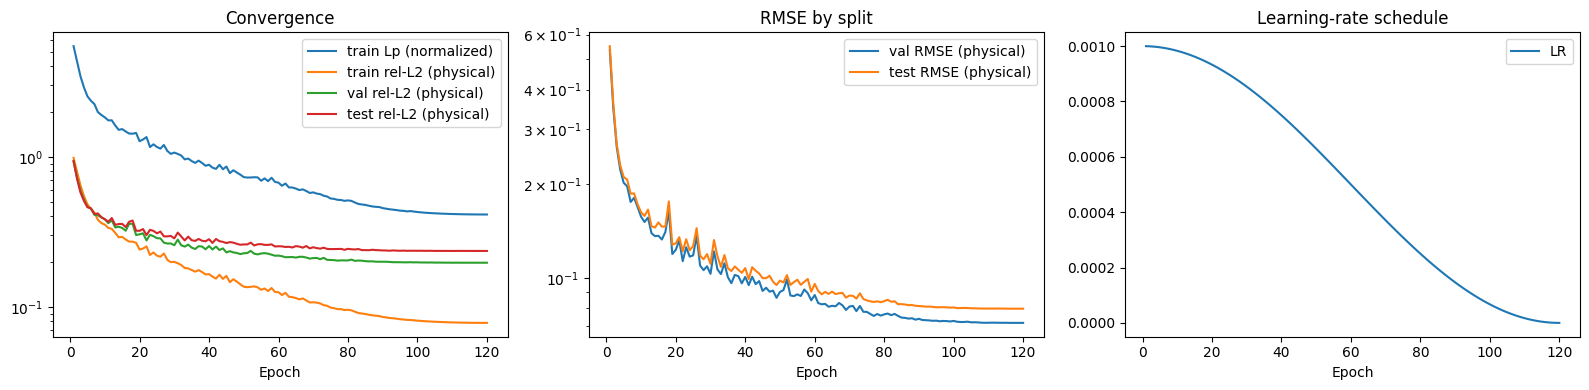

[TEST] representative sample indices (min_frame=10) -> best=55 (rel=4.359e-02), median=32 (rel=1.398e-01), worst=8 (rel=1.358e+00)
[TEST] sample_idx=32, frame=1695, folder=pair_3_fno_32, file=frame_1695_grid.npz, active y-slices=[2, 15, 29], rel-L2=1.398e-01
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_qualitative_test_median_primary_views.png


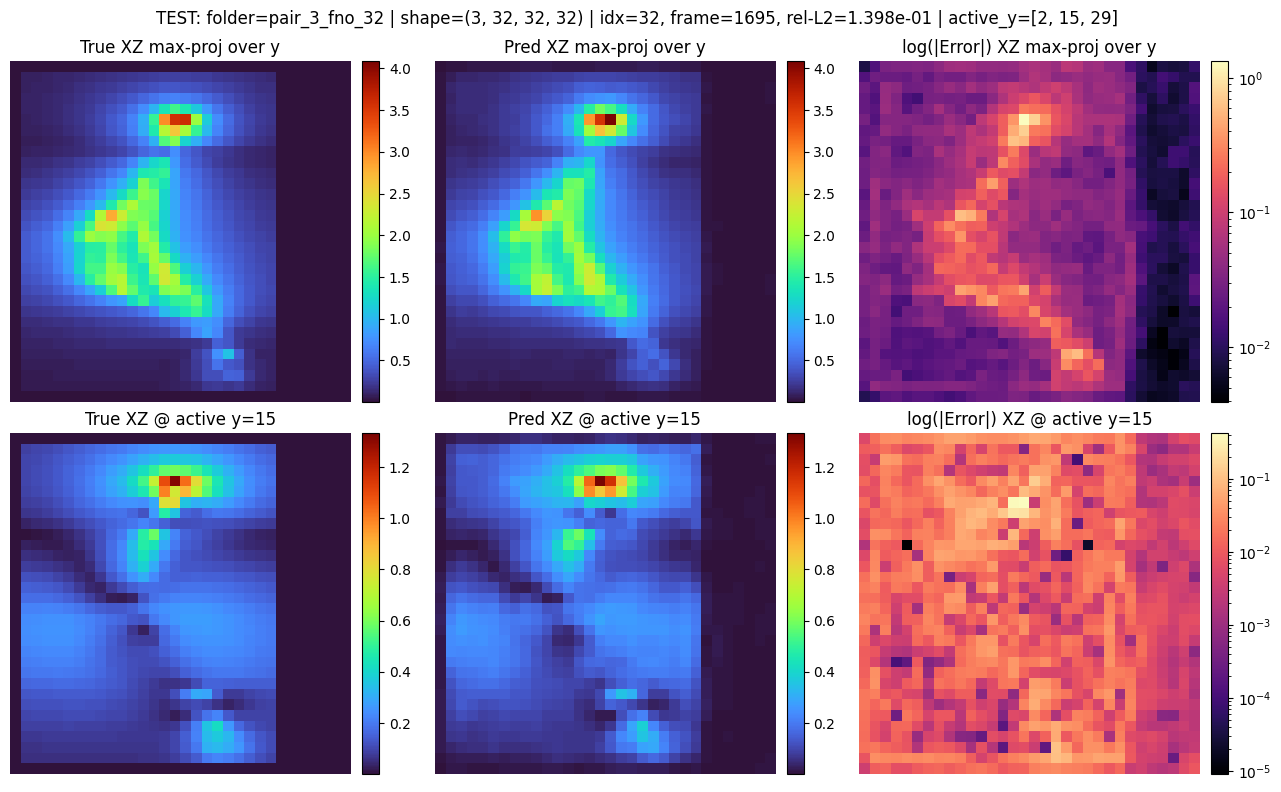

[TEST timeline] folder=pair_3_fno_32, selected idx=[13, 26, 42, 32]
[note] idx = dataset index in TEST split; frame = timestep parsed from filename
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_test_same_folder_timeline_3x4.png


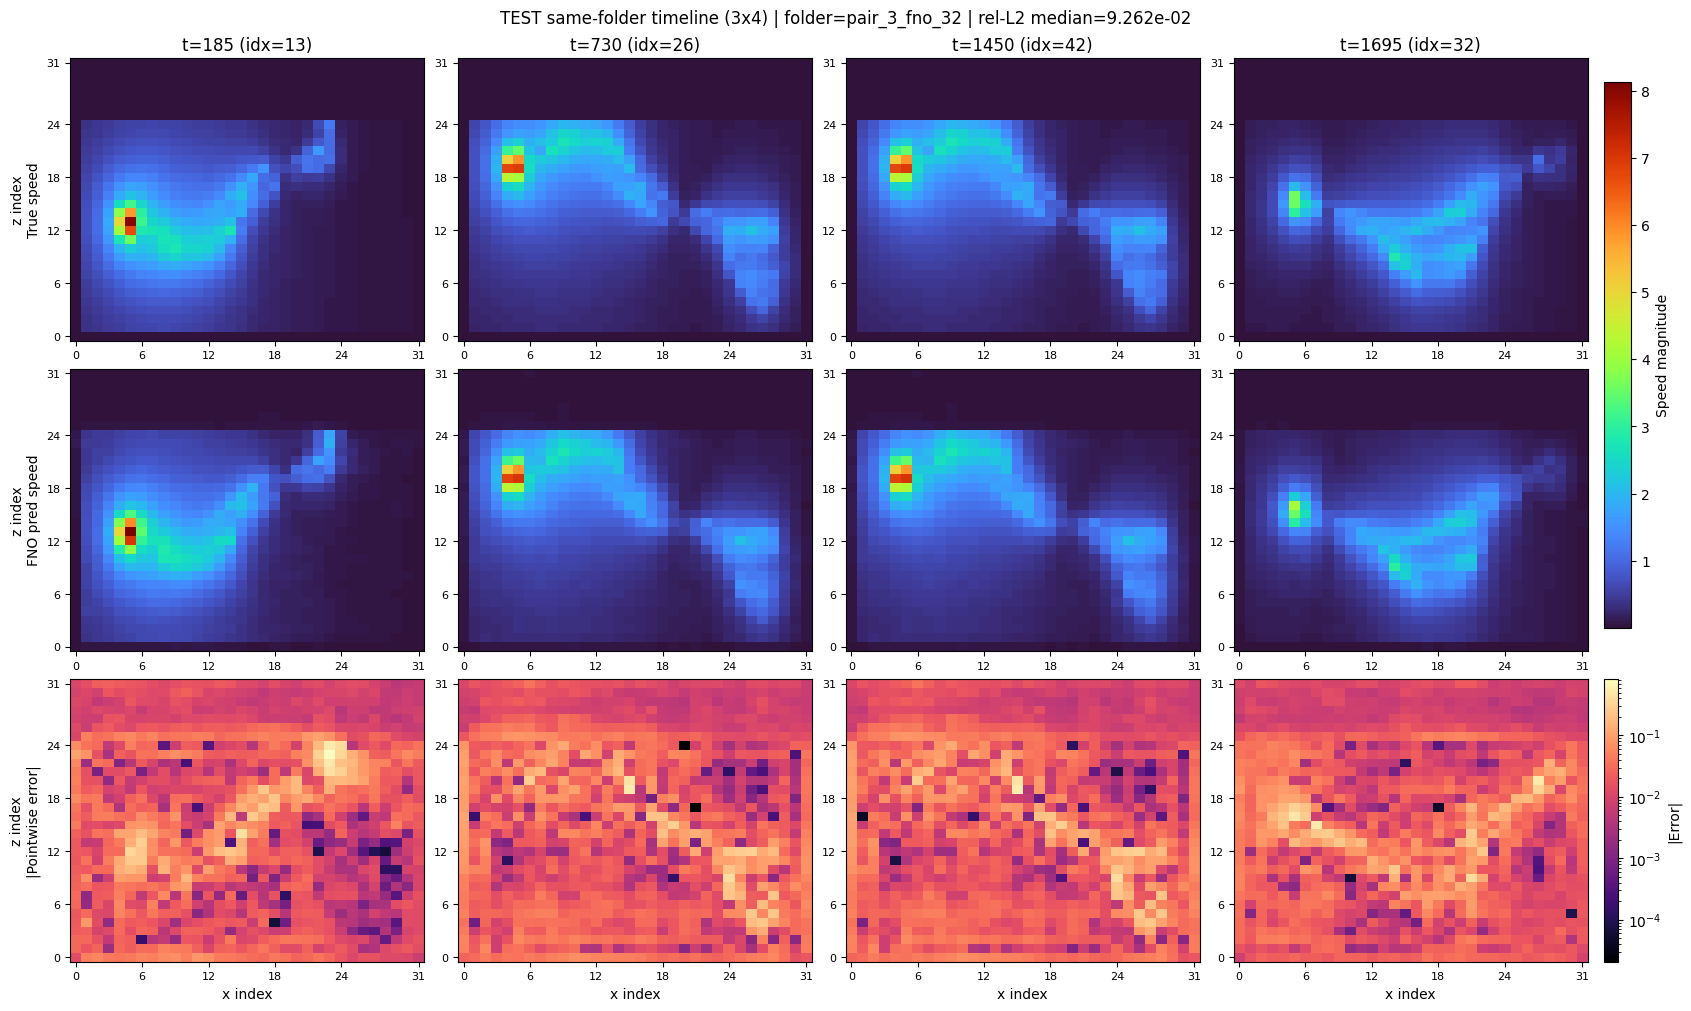

In [20]:
# =========================
# Core plots (3D): convergence + y-plane diagnostics
# =========================
# Load best checkpoint for reporting, if available.
if CFG.get('use_best_checkpoint_for_reports', True) and CKPT_PATH.exists():
    try:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    MODEL.load_state_dict(state_dict)
    MODEL.eval()
    print('[info] loaded best checkpoint for reporting:', CKPT_PATH)

from matplotlib.colors import LogNorm

def speed_from_velocity(u_chw):
    # Convert velocity channels [Ux, Uy, Uz] into scalar speed [Nx, Ny, Nz].
    return torch.linalg.norm(u_chw, dim=0).cpu().numpy()


def active_y_slice_indices(vol, n_slices=3, frac_threshold=0.05):
    # Pick y-planes from the actually active flow region instead of using
    # fixed quarter/mid/end planes that can miss the physics entirely.
    plane_energy = np.sum(np.abs(vol), axis=(0, 2))
    if float(plane_energy.max()) <= 0.0:
        fallback = np.linspace(0, max(vol.shape[1] - 1, 0), num=n_slices, dtype=int)
        return fallback.tolist(), plane_energy

    active = np.where(plane_energy >= frac_threshold * float(plane_energy.max()))[0]
    if len(active) == 0:
        active = np.array([int(np.argmax(plane_energy))], dtype=int)

    q = np.linspace(0, len(active) - 1, num=n_slices, dtype=int)
    idx = active[q]
    return idx.tolist(), plane_energy


def xz_views_at_selected_y(vol, y_idx):
    return [vol[:, yi, :] for yi in y_idx]


def xz_max_projection(vol):
    # Max projection across y shows the full flow footprint in one panel.
    return np.max(vol, axis=1)


@torch.no_grad()
def sample_rel_l2(model, x_norm, y_norm):
    p_norm = predict(model, x_norm.unsqueeze(0).to(DEVICE, non_blocking=NON_BLOCKING))[0].cpu()
    p_phys = to_physical_y(p_norm)
    y_phys = to_physical_y(y_norm)
    rel = (
        torch.linalg.norm((p_phys - y_phys).reshape(-1))
        / torch.linalg.norm(y_phys.reshape(-1)).clamp_min(1e-12)
    ).item()
    return p_norm, rel


def representative_indices(model, ds, files, min_frame, split_name):
    if len(ds) == 0:
        return {'best': None, 'median': None, 'worst': None}

    # Filter indices to skip early frames if requested.
    if min_frame not in (None, 0):
        valid = [i for i, f in enumerate(files) if parse_frame_id(f) >= min_frame]
        if len(valid) == 0:
            print(f"[warn] {split_name}: no frames >= {min_frame}; falling back to full set")
            valid = list(range(len(ds)))
    else:
        valid = list(range(len(ds)))

    max_items = min(len(valid), 24 if CFG['fast_sanity_mode'] else len(valid))
    rels = []
    model.eval()
    for i in valid[:max_items]:
        x_norm, y_norm = ds[i]
        _, rel = sample_rel_l2(model, x_norm, y_norm)
        rels.append((i, rel))

    rels_sorted = sorted(rels, key=lambda t: t[1])
    best_i = rels_sorted[0][0]
    med_i = rels_sorted[len(rels_sorted) // 2][0]
    worst_i = rels_sorted[-1][0]

    print(
        f"[{split_name}] representative sample indices (min_frame={min_frame}) -> "
        f"best={best_i} (rel={rels_sorted[0][1]:.3e}), "
        f"median={med_i} (rel={rels_sorted[len(rels_sorted)//2][1]:.3e}), "
        f"worst={worst_i} (rel={rels_sorted[-1][1]:.3e})"
    )
    return {'best': best_i, 'median': med_i, 'worst': worst_i}



def plot_volume_diagnostics(ds, files, split_name, sample_idx, save_tag, min_frame=None):
    if sample_idx is None:
        print(f"[skip] {split_name}: no sample index")
        return
    if sample_idx >= len(files):
        print(f"[skip] {split_name}: sample_idx out of range")
        return
    frame = parse_frame_id(files[sample_idx])
    if min_frame not in (None, 0) and frame < min_frame:
        print(f"[skip] {split_name}: frame {frame} < min_frame {min_frame}")
        return

    x_norm, y_norm = ds[sample_idx]
    with torch.no_grad():
        p_norm = predict(MODEL, x_norm.unsqueeze(0).to(DEVICE, non_blocking=NON_BLOCKING))[0].cpu()

    y_phys = to_physical_y(y_norm)
    p_phys = to_physical_y(p_norm)

    true_speed = speed_from_velocity(y_phys)
    pred_speed = speed_from_velocity(p_phys)
    err_speed = np.abs(pred_speed - true_speed)

    rel = (
        torch.linalg.norm((p_phys - y_phys).reshape(-1))
        / torch.linalg.norm(y_phys.reshape(-1)).clamp_min(1e-12)
    ).item()

    y_idx, plane_energy = active_y_slice_indices(true_speed, n_slices=3, frac_threshold=0.05)
    true_views = xz_views_at_selected_y(true_speed, y_idx)
    pred_views = xz_views_at_selected_y(pred_speed, y_idx)
    err_views = xz_views_at_selected_y(err_speed, y_idx)
    true_proj = xz_max_projection(true_speed)
    pred_proj = xz_max_projection(pred_speed)
    err_proj = xz_max_projection(err_speed)

    file_path = Path(files[sample_idx]) if sample_idx < len(files) else Path('unknown')
    fname = file_path.name
    folder_name = file_path.parent.name
    print(
        f"[{split_name}] sample_idx={sample_idx}, frame={frame}, folder={folder_name}, file={fname}, "
        f"active y-slices={y_idx}, rel-L2={rel:.3e}"
    )

    fig, axs = plt.subplots(2, 3, figsize=(13, 8))
    proj_vmin = min(float(true_proj.min()), float(pred_proj.min()))
    proj_vmax = max(float(true_proj.max()), float(pred_proj.max()))

    im0 = axs[0, 0].imshow(true_proj, cmap='turbo', vmin=proj_vmin, vmax=proj_vmax)
    axs[0, 0].set_title('True XZ max-proj over y')
    axs[0, 0].axis('off')
    plt.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.03)

    im1 = axs[0, 1].imshow(pred_proj, cmap='turbo', vmin=proj_vmin, vmax=proj_vmax)
    axs[0, 1].set_title('Pred XZ max-proj over y')
    axs[0, 1].axis('off')
    plt.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.03)

    proj_err_min = max(float(err_proj.min()), 1e-8)
    proj_err_max = max(float(err_proj.max()), proj_err_min * 10)
    im2 = axs[0, 2].imshow(err_proj, cmap='magma', norm=LogNorm(vmin=proj_err_min, vmax=proj_err_max))
    axs[0, 2].set_title('log(|Error|) XZ max-proj over y')
    axs[0, 2].axis('off')
    plt.colorbar(im2, ax=axs[0, 2], fraction=0.046, pad=0.03)

    mid_k = len(y_idx) // 2
    sel_true = true_views[mid_k]
    sel_pred = pred_views[mid_k]
    sel_err = err_views[mid_k]
    sel_y = y_idx[mid_k]
    slice_vmin = min(float(sel_true.min()), float(sel_pred.min()))
    slice_vmax = max(float(sel_true.max()), float(sel_pred.max()))

    im3 = axs[1, 0].imshow(sel_true, cmap='turbo', vmin=slice_vmin, vmax=slice_vmax)
    axs[1, 0].set_title(f'True XZ @ active y={sel_y}')
    axs[1, 0].axis('off')
    plt.colorbar(im3, ax=axs[1, 0], fraction=0.046, pad=0.03)

    im4 = axs[1, 1].imshow(sel_pred, cmap='turbo', vmin=slice_vmin, vmax=slice_vmax)
    axs[1, 1].set_title(f'Pred XZ @ active y={sel_y}')
    axs[1, 1].axis('off')
    plt.colorbar(im4, ax=axs[1, 1], fraction=0.046, pad=0.03)

    slice_err_min = max(float(sel_err.min()), 1e-8)
    slice_err_max = max(float(sel_err.max()), slice_err_min * 10)
    im5 = axs[1, 2].imshow(sel_err, cmap='magma', norm=LogNorm(vmin=slice_err_min, vmax=slice_err_max))
    axs[1, 2].set_title(f'log(|Error|) XZ @ active y={sel_y}')
    axs[1, 2].axis('off')
    plt.colorbar(im5, ax=axs[1, 2], fraction=0.046, pad=0.03)

    fig.suptitle(
        f"{split_name}: folder={folder_name} | shape={tuple(y_phys.shape)} | idx={sample_idx}, frame={frame}, rel-L2={rel:.3e} | active_y={y_idx}",
        fontsize=12,
    )
    fig.tight_layout()
    save_fig(fig, f"qualitative_{save_tag}_primary_views.png")
    plt.show()

# Convergence curves.
fig_c, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].plot(HIST['epoch'], HIST['train_lp'], label='train Lp (normalized)')
axs[0].plot(HIST['epoch'], HIST['train_rel_l2'], label='train rel-L2 (physical)')
axs[0].plot(HIST['epoch'], HIST['val_rel_l2'], label='val rel-L2 (physical)')
if HAS_TEST:
    axs[0].plot(HIST['epoch'], HIST['test_rel_l2'], label='test rel-L2 (physical)')
if HAS_TEST_SR:
    axs[0].plot(HIST['epoch'], HIST['test_sr_rel_l2'], label='test_sr rel-L2 (physical)')
axs[0].set_yscale('log')
axs[0].set_xlabel('Epoch')
axs[0].set_title('Convergence')
axs[0].legend()

axs[1].plot(HIST['epoch'], HIST['val_rmse'], label='val RMSE (physical)')
if HAS_TEST:
    axs[1].plot(HIST['epoch'], HIST['test_rmse'], label='test RMSE (physical)')
if HAS_TEST_SR:
    axs[1].plot(HIST['epoch'], HIST['test_sr_rmse'], label='test_sr RMSE (physical)')
axs[1].set_yscale('log')
axs[1].set_xlabel('Epoch')
axs[1].set_title('RMSE by split')
axs[1].legend()

axs[2].plot(HIST['epoch'], HIST['lr'], label='LR')
axs[2].set_xlabel('Epoch')
axs[2].set_title('Learning-rate schedule')
axs[2].legend()

fig_c.tight_layout()
save_fig(fig_c, 'convergence_with_test_sr.png' if HAS_TEST_SR else 'convergence.png')
plt.show()

# Primary-stage qualitative diagnostics: keep just one representative split.
MODEL.eval()
if HAS_TEST:
    diag_split_name = 'TEST'
    diag_ds = TEST_DS
    diag_files = TEST_FILES
    diag_min_frame = CFG['min_frame_test']
elif len(VAL_FILES) > 0:
    diag_split_name = 'VAL'
    diag_ds = VAL_DS
    diag_files = VAL_FILES
    diag_min_frame = CFG['min_frame_trainval']
else:
    diag_split_name = 'TRAIN'
    diag_ds = TRAIN_DS
    diag_files = TRAIN_FILES
    diag_min_frame = CFG['min_frame_trainval']

diag_rep = representative_indices(MODEL, diag_ds, diag_files, diag_min_frame, split_name=diag_split_name)
plot_volume_diagnostics(diag_ds, diag_files, diag_split_name, diag_rep['median'], save_tag=f'{diag_split_name.lower()}_median', min_frame=diag_min_frame)

# Additional fixed-folder-style panel for pooled-random TEST split.
def plot_test_same_folder_timeline(ds, files, min_frame=0, n_cols=4):
    if ds is None or len(files) == 0:
        print('[skip] same-folder test timeline: no test split available')
        return

    by_folder = defaultdict(list)
    for i, f in enumerate(files):
        fr = parse_frame_id(f)
        if min_frame not in (None, 0) and fr < min_frame:
            continue
        by_folder[Path(f).parent.name].append((i, fr))

    if len(by_folder) == 0:
        print('[skip] same-folder test timeline: no files after frame filter')
        return

    folder = max(by_folder.keys(), key=lambda k: len(by_folder[k]))
    rows = sorted(by_folder[folder], key=lambda t: t[1])
    n_cols = min(int(n_cols), len(rows))
    if n_cols < 2:
        print('[skip] same-folder test timeline: need at least 2 snapshots in one folder')
        return

    start_idx = max(1, int(round(0.10 * max(len(rows) - 1, 1))))
    cand = rows[start_idx:] if start_idx < len(rows) else rows
    if len(cand) < n_cols:
        cand = rows

    pos = np.linspace(0, len(cand) - 1, num=n_cols, dtype=int).tolist()
    idxs = [cand[p][0] for p in pos]
    print(f'[TEST timeline] folder={folder}, selected idx={idxs}')
    print('[note] idx = dataset index in TEST split; frame = timestep parsed from filename')

    samples = []
    for idx in idxs:
        x_norm, y_norm = ds[idx]
        with torch.no_grad():
            p_norm = predict(MODEL, x_norm.unsqueeze(0).to(DEVICE, non_blocking=NON_BLOCKING))[0].cpu()

        y_phys = to_physical_y(y_norm)
        p_phys = to_physical_y(p_norm)
        true_proj = xz_max_projection(speed_from_velocity(y_phys))
        pred_proj = xz_max_projection(speed_from_velocity(p_phys))
        err_proj = np.abs(pred_proj - true_proj)
        rel = (
            torch.linalg.norm((p_phys - y_phys).reshape(-1))
            / torch.linalg.norm(y_phys.reshape(-1)).clamp_min(1e-12)
        ).item()
        fp = Path(files[idx])
        samples.append({'idx': idx, 'frame': parse_frame_id(fp), 'file': fp.name, 'true': true_proj, 'pred': pred_proj, 'err': err_proj, 'rel': rel})

    all_field = np.concatenate([s['true'].reshape(-1) for s in samples] + [s['pred'].reshape(-1) for s in samples])
    vmin = float(np.min(all_field))
    vmax = float(np.max(all_field))
    all_err = np.concatenate([s['err'].reshape(-1) for s in samples])
    err_min = max(float(np.min(all_err)), 1e-8)
    err_max = max(float(np.max(all_err)), err_min * 10)

    fig, axs = plt.subplots(3, n_cols, figsize=(4.2 * n_cols, 10), constrained_layout=True)
    if n_cols == 1:
        axs = np.asarray(axs).reshape(3, 1)

    for j, s in enumerate(samples):
        im_t = axs[0, j].imshow(s['true'].T, cmap='turbo', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
        im_p = axs[1, j].imshow(s['pred'].T, cmap='turbo', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
        im_e = axs[2, j].imshow(s['err'].T, cmap='magma', norm=LogNorm(vmin=err_min, vmax=err_max), origin='lower', aspect='auto')

        axs[0, j].set_title(f"t={s['frame']} (idx={s['idx']})")
        for r in range(3):
            nx, nz = s['true'].shape
            xt = np.linspace(0, max(nx - 1, 0), num=min(6, max(nx, 1)), dtype=int)
            yt = np.linspace(0, max(nz - 1, 0), num=min(6, max(nz, 1)), dtype=int)
            axs[r, j].set_xticks(np.unique(xt))
            axs[r, j].set_yticks(np.unique(yt))
            axs[r, j].tick_params(labelsize=8)
        if j == 0:
            axs[0, j].set_ylabel('z index\nTrue speed')
            axs[1, j].set_ylabel('z index\nFNO pred speed')
            axs[2, j].set_ylabel('z index\n|Pointwise error|')
        axs[2, j].set_xlabel('x index')

    cbar_field = fig.colorbar(im_t, ax=axs[0, :].tolist() + axs[1, :].tolist(), fraction=0.018, pad=0.01)
    cbar_field.set_label('Speed magnitude')
    cbar_err = fig.colorbar(im_e, ax=axs[2, :].tolist(), fraction=0.018, pad=0.01)
    cbar_err.set_label('|Error|')
    rel_med = np.median([s['rel'] for s in samples])
    fig.suptitle(f'TEST same-folder timeline (3x{n_cols}) | folder={folder} | rel-L2 median={rel_med:.3e}', fontsize=12)
    save_fig(fig, f'test_same_folder_timeline_3x{n_cols}.png')
    plt.show()

if HAS_TEST:
    plot_test_same_folder_timeline(TEST_DS, TEST_FILES, min_frame=CFG['min_frame_test'], n_cols=4)


[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_relative_error_vs_epoch.png


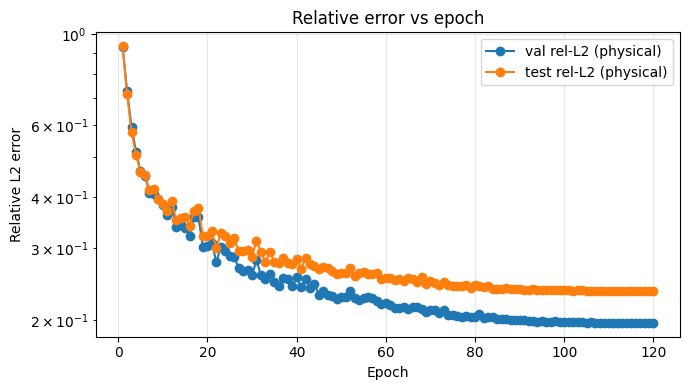

TEST (32^3 pooled split) diagnostic sample idx=32, folder=pair_3_fno_32, frame=1695, file=frame_1695_grid.npz, rel-L2=1.398e-01
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_error_distribution_and_parity.png


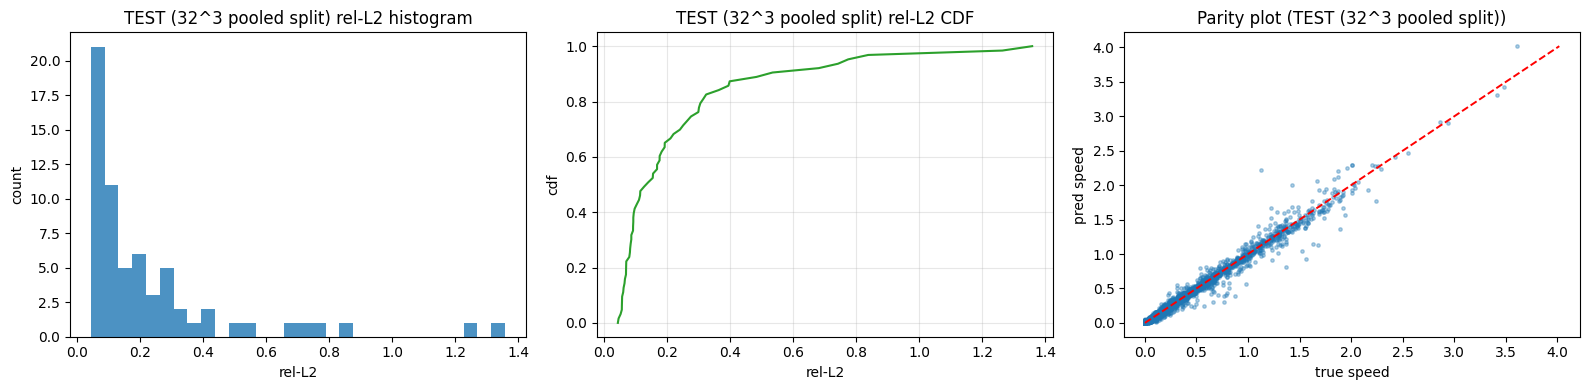

In [ ]:
# =========================
# Relative Error + Distribution/Parity Diagnostics
# =========================
if CFG.get('use_best_checkpoint_for_reports', True) and CKPT_PATH.exists():
    try:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    except TypeError:
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
    MODEL.load_state_dict(state_dict)
    MODEL.eval()
    print('[info] loaded best checkpoint for reporting:', CKPT_PATH)

if len(HIST['epoch']) == 0:
    raise RuntimeError('History is empty; run training first.')

fig_r, ax_r = plt.subplots(figsize=(7, 4))
ax_r.plot(HIST['epoch'], HIST['val_rel_l2'], marker='o', label='val rel-L2 (physical)')
if HAS_TEST:
    ax_r.plot(HIST['epoch'], HIST['test_rel_l2'], marker='o', label='test rel-L2 (physical)')
ax_r.set_yscale('log')
ax_r.set_xlabel('Epoch')
ax_r.set_ylabel('Relative L2 error')
ax_r.set_title('Relative error vs epoch')
ax_r.grid(True, alpha=0.3)
ax_r.legend()
fig_r.tight_layout()
save_fig(fig_r, 'relative_error_vs_epoch.png')
plt.show()

if HAS_TEST:
    diag_loader = TEST_LOADER
    diag_ds = TEST_DS
    diag_files = TEST_FILES
    diag_label = f"TEST ({CFG.get('train_expected_res', '?')}^3 pooled split)"
else:
    diag_loader = VAL_LOADER
    diag_ds = VAL_DS
    diag_files = VAL_FILES
    diag_label = f"VAL ({CFG.get('train_expected_res', '?')}^3 pooled split)"

diag = evaluate(MODEL, diag_loader, collect=True)
rel_vals = np.asarray(diag['rel_per_sample'], dtype=np.float32)
if len(rel_vals) == 0:
    raise RuntimeError('No per-sample relative error values available for diagnostics.')

diag_idx = int(np.argsort(rel_vals)[len(rel_vals) // 2])
diag_path = Path(diag_files[diag_idx])
print(
    f"{diag_label} diagnostic sample idx={diag_idx}, folder={diag_path.parent.name}, frame={parse_frame_id(diag_path)}, "
    f"file={diag_path.name}, rel-L2={rel_vals[diag_idx]:.3e}"
)

sx_norm, sy_norm = diag_ds[diag_idx]
with torch.no_grad():
    sp_norm = predict(MODEL, sx_norm.unsqueeze(0).to(DEVICE, non_blocking=NON_BLOCKING))[0].cpu()

sy_phys = to_physical_y(sy_norm)
sp_phys = to_physical_y(sp_norm)
true_speed = speed_from_velocity(sy_phys).reshape(-1)
pred_speed = speed_from_velocity(sp_phys).reshape(-1)

rng = np.random.default_rng(CFG['seed'])
if true_speed.size > 8000:
    idx = rng.choice(true_speed.size, size=8000, replace=False)
    true_speed = true_speed[idx]
    pred_speed = pred_speed[idx]

fig_d, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].hist(rel_vals, bins=30, color='tab:blue', alpha=0.8)
axs[0].set_title(f'{diag_label} rel-L2 histogram')
axs[0].set_xlabel('rel-L2')
axs[0].set_ylabel('count')
sorted_rel = np.sort(rel_vals)
cdf = np.linspace(0, 1, len(sorted_rel), endpoint=True)
axs[1].plot(sorted_rel, cdf, color='tab:green')
axs[1].set_title(f'{diag_label} rel-L2 CDF')
axs[1].set_xlabel('rel-L2')
axs[1].set_ylabel('cdf')
axs[1].grid(True, alpha=0.3)

vmin = min(float(true_speed.min()), float(pred_speed.min()))
vmax = max(float(true_speed.max()), float(pred_speed.max()))
axs[2].scatter(true_speed, pred_speed, s=6, alpha=0.35)
axs[2].plot([vmin, vmax], [vmin, vmax], 'r--', linewidth=1.4)
axs[2].set_title(f'Parity plot ({diag_label})')
axs[2].set_xlabel('true speed')
axs[2].set_ylabel('pred speed')

fig_d.tight_layout()
save_fig(fig_d, 'error_distribution_and_parity.png')
plt.show()


[TEST] frame filter >= 10: 64 files
[TEST] selected indices (dataset order): [0, 31, 63]
  idx=000, folder=pair_3_fno_32, frame=720, file=frame_720_grid.npz
  idx=031, folder=pair_5_fno_32, frame=254, file=frame_254_grid.npz
  idx=063, folder=pair_3_fno_32, frame=1635, file=frame_1635_grid.npz
[TEST] sample_idx=0, frame=720, folder=pair_3_fno_32, file=frame_720_grid.npz, active y-slices=[2, 15, 29], rel-L2=9.404e-02
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_qualitative_test_idx000_primary_views.png


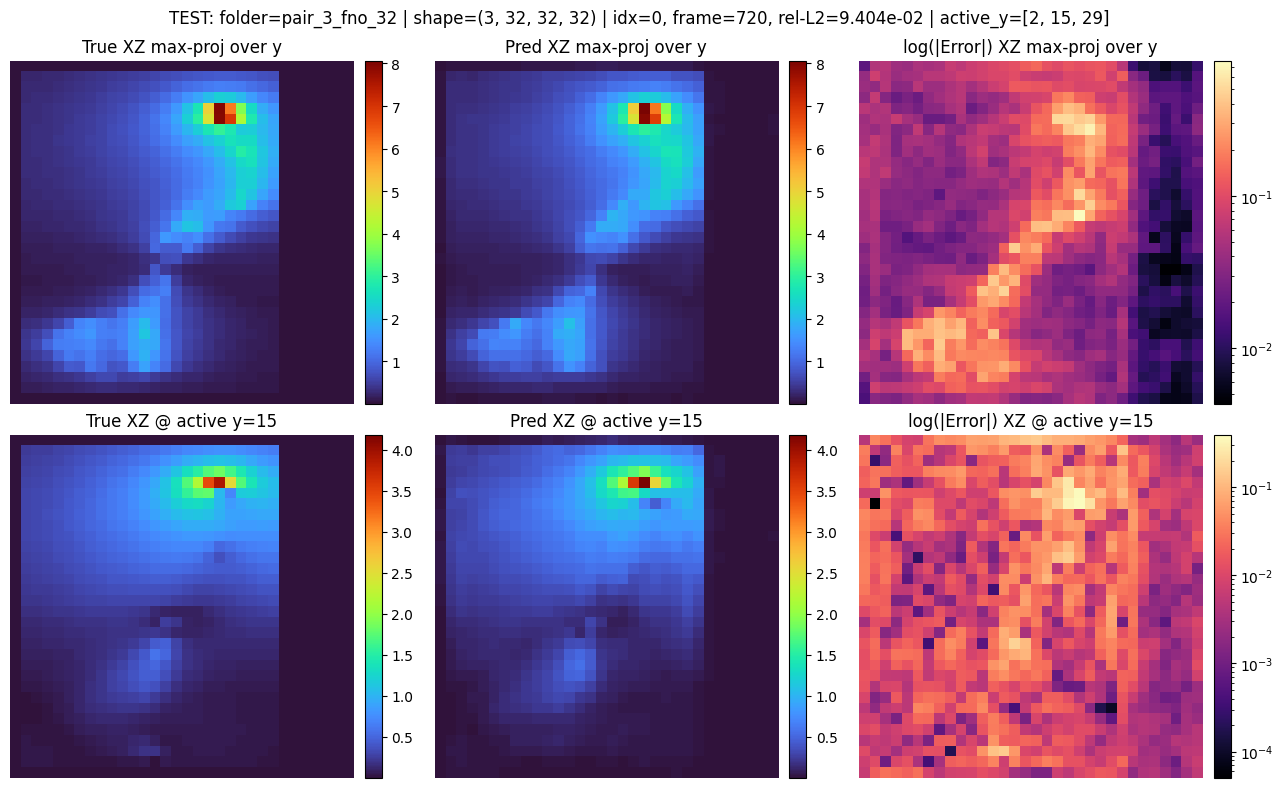

[TEST] sample_idx=31, frame=254, folder=pair_5_fno_32, file=frame_254_grid.npz, active y-slices=[3, 15, 28], rel-L2=3.052e-01
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_qualitative_test_idx031_primary_views.png


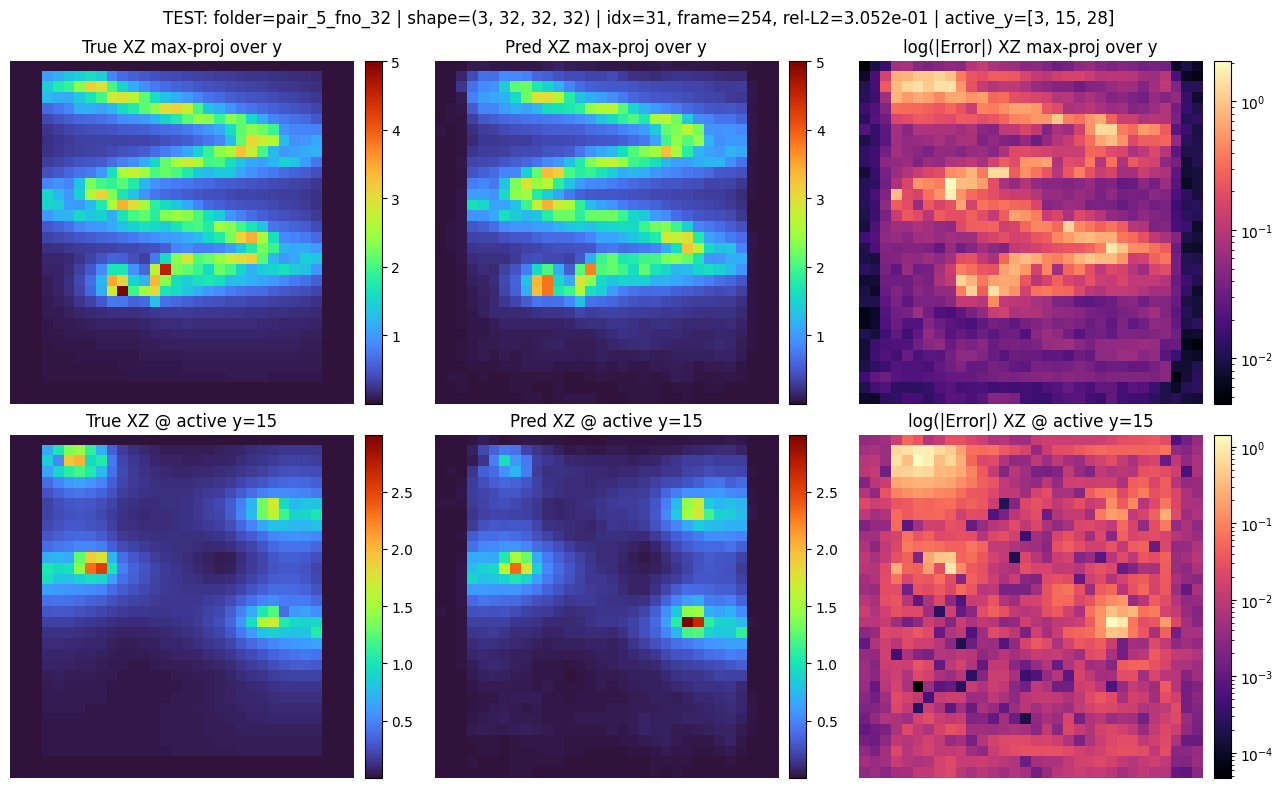

[TEST] sample_idx=63, frame=1635, folder=pair_3_fno_32, file=frame_1635_grid.npz, active y-slices=[2, 15, 29], rel-L2=6.611e-02
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_qualitative_test_idx063_primary_views.png


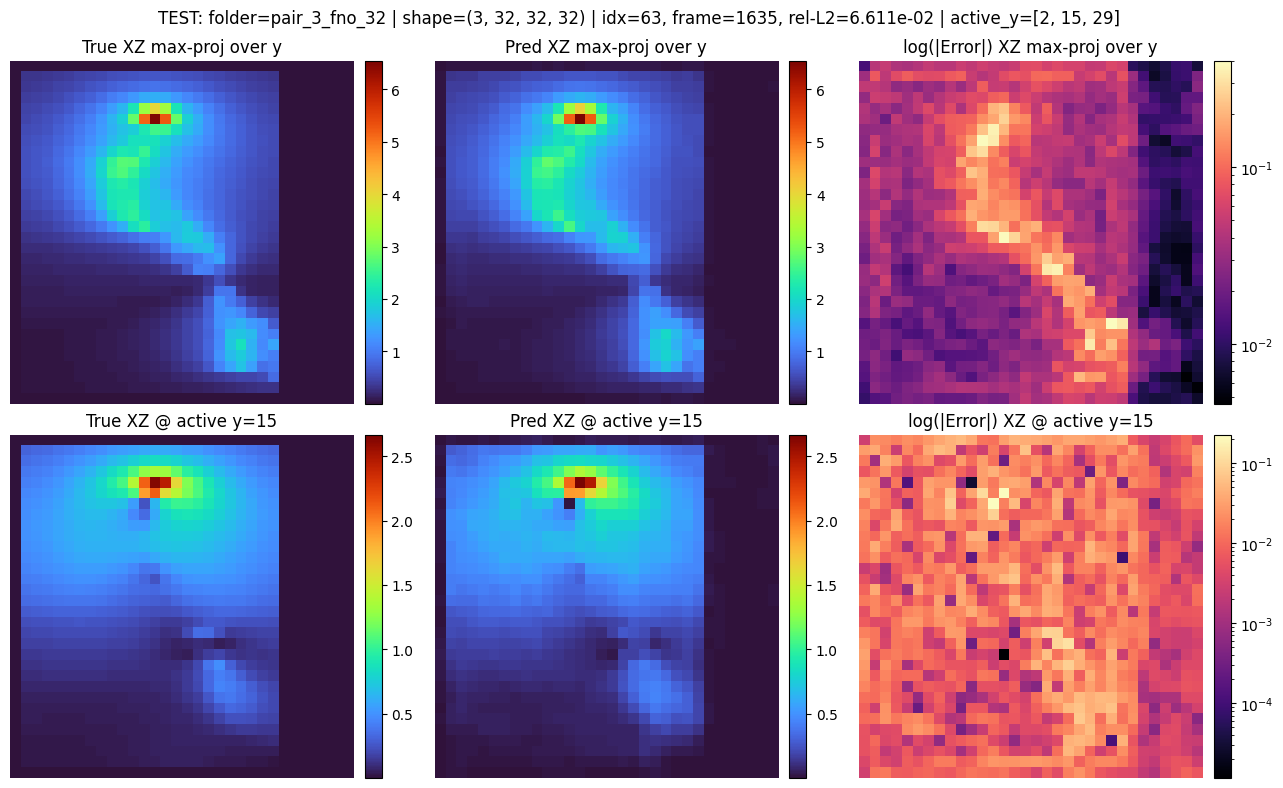

[VAL] frame filter >= 10: 64 files
[VAL] selected indices (dataset order): [0, 63]
  idx=000, folder=pair_1_fno_32, frame=172, file=frame_172_grid.npz
  idx=063, folder=pair_3_fno_32, frame=1135, file=frame_1135_grid.npz
[VAL] sample_idx=0, frame=172, folder=pair_1_fno_32, file=frame_172_grid.npz, active y-slices=[1, 15, 30], rel-L2=8.842e-02
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_qualitative_val_idx000_primary_views.png


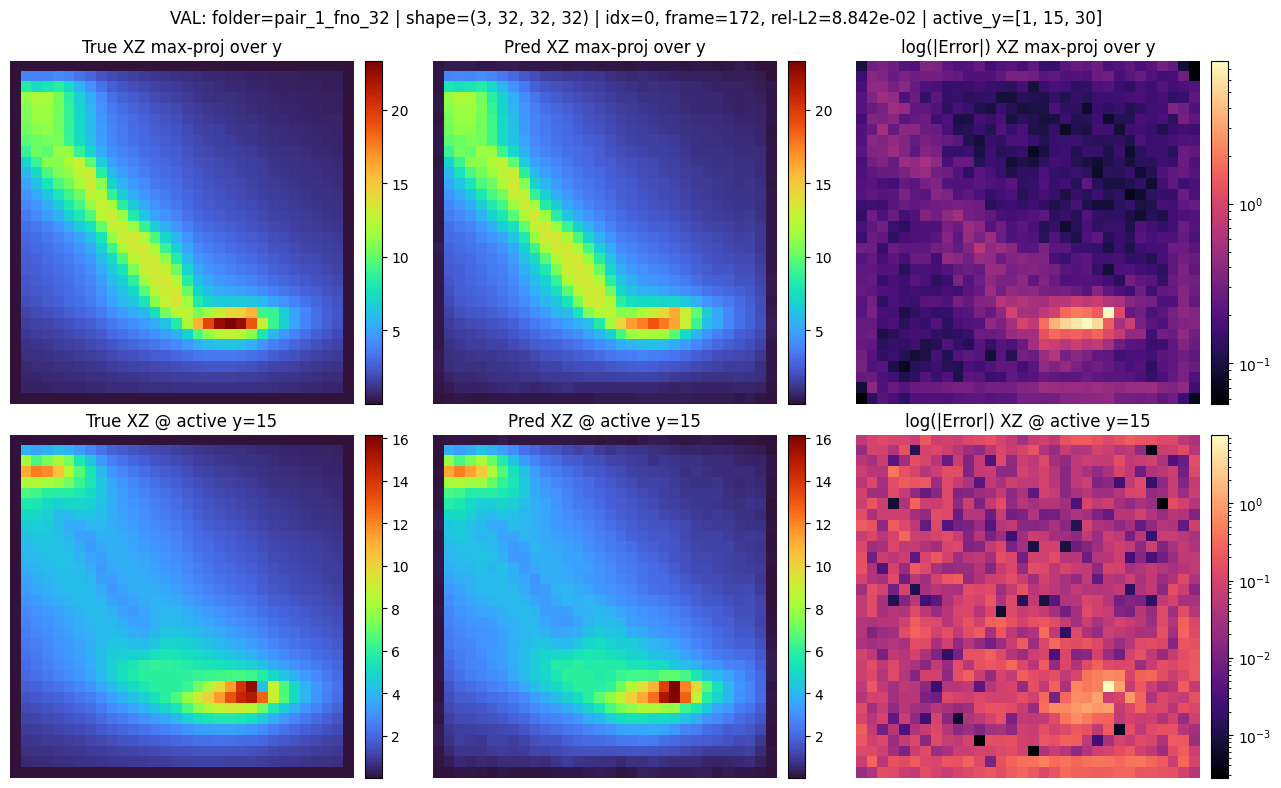

[VAL] sample_idx=63, frame=1135, folder=pair_3_fno_32, file=frame_1135_grid.npz, active y-slices=[2, 15, 29], rel-L2=1.683e-01
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_qualitative_val_idx063_primary_views.png


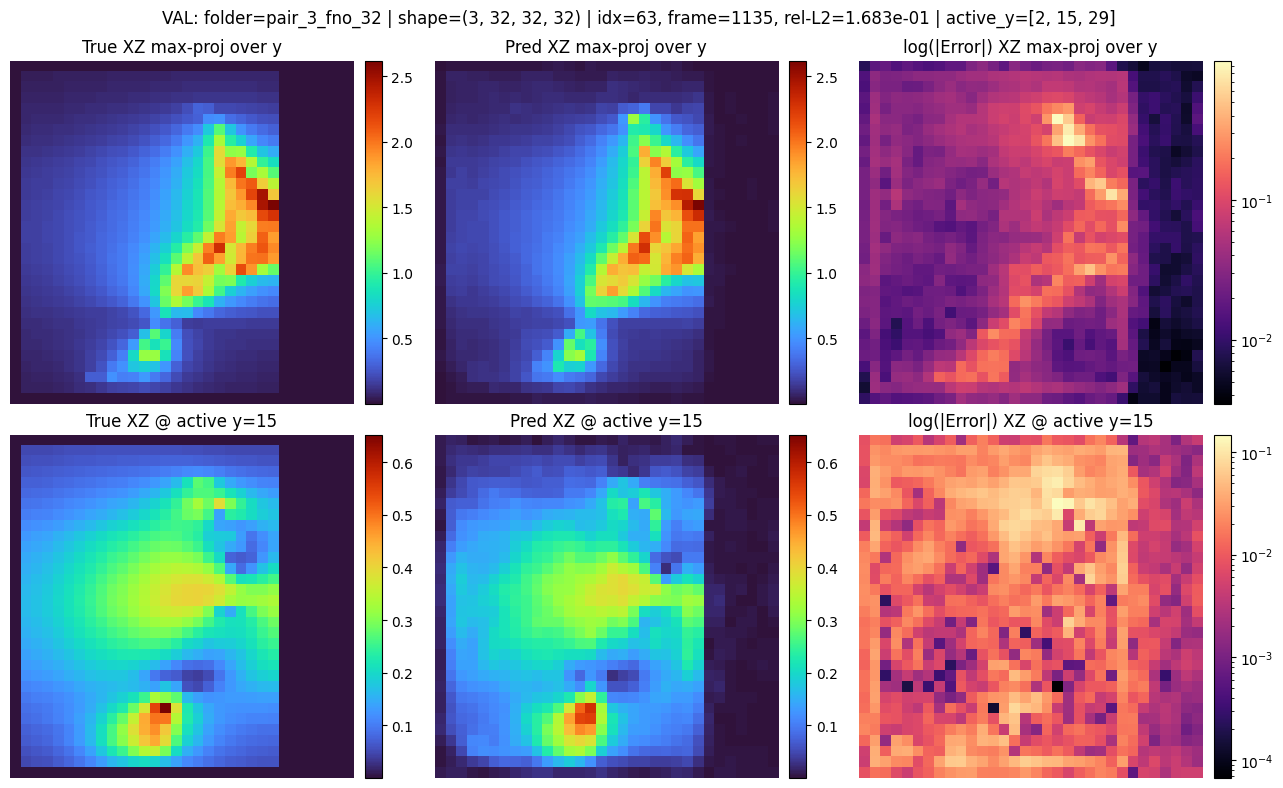

[TRAIN] frame filter >= 10: 256 files
[TRAIN] selected indices (dataset order): [0, 255]
  idx=000, folder=pair_3_fno_32, frame=1455, file=frame_1455_grid.npz
  idx=255, folder=pair_3_fno_32, frame=405, file=frame_405_grid.npz
[TRAIN] sample_idx=0, frame=1455, folder=pair_3_fno_32, file=frame_1455_grid.npz, active y-slices=[2, 15, 29], rel-L2=6.475e-02
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_qualitative_train_idx000_primary_views.png


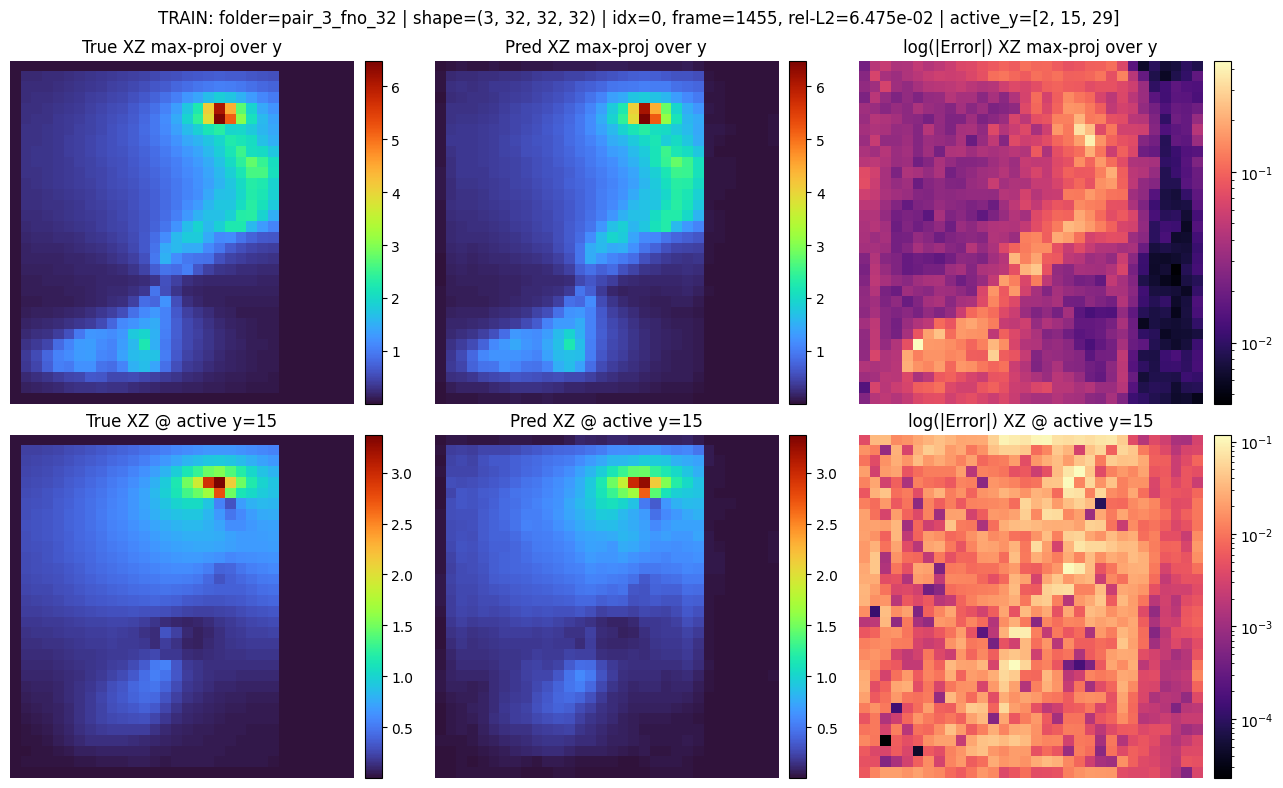

[TRAIN] sample_idx=255, frame=405, folder=pair_3_fno_32, file=frame_405_grid.npz, active y-slices=[2, 15, 29], rel-L2=8.879e-02
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_qualitative_train_idx255_primary_views.png


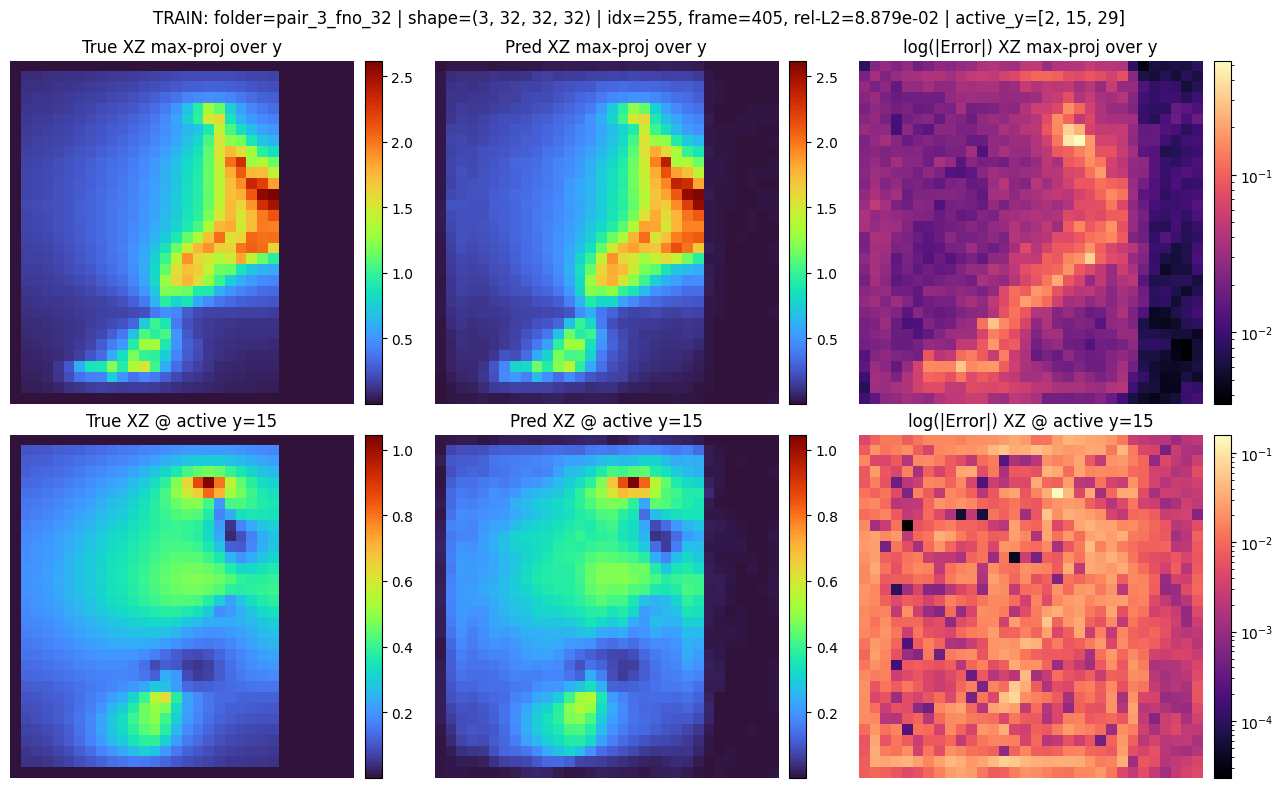

In [15]:
# =========================
# Multi-Snapshot Qualitative Diagnostics
# =========================
def choose_indices(n_items, n_times=3):
    n_times = max(1, min(n_times, n_items))
    return np.linspace(0, n_items - 1, n_times, dtype=int).tolist()


def plot_snapshot_panel(files, ds, panel_name, min_frame=0, n_times=3, order_mode='dataset'):
    if len(files) == 0:
        print(f'[skip] no files for {panel_name}')
        return

    work_files = sorted(files, key=parse_frame_id) if order_mode == 'frame' else list(files)
    if min_frame not in (None, 0):
        work_files = [f for f in work_files if parse_frame_id(f) >= min_frame]
        print(f"[{panel_name}] frame filter >= {min_frame}: {len(work_files)} files")
    if len(work_files) == 0:
        print(f"[skip] {panel_name}: no files after frame filter")
        return

    idxs = choose_indices(len(work_files), n_times=n_times)
    print(f'[{panel_name}] selected indices ({order_mode} order): {idxs}')
    for i in idxs:
        fp = Path(work_files[i])
        print(f"  idx={i:03d}, folder={fp.parent.name}, frame={parse_frame_id(fp)}, file={fp.name}")

    for idx_local in idxs:
        plot_volume_diagnostics(ds, work_files, panel_name, idx_local, save_tag=f'{panel_name.lower()}_idx{idx_local:03d}', min_frame=min_frame)

if HAS_TEST:
    plot_snapshot_panel(TEST_FILES, TEST_DS, panel_name='TEST', min_frame=CFG['min_frame_test'], n_times=3, order_mode='dataset')
plot_snapshot_panel(VAL_FILES, VAL_DS, panel_name='VAL', min_frame=CFG['min_frame_trainval'], n_times=2, order_mode='dataset')
plot_snapshot_panel(TRAIN_FILES, TRAIN_DS, panel_name='TRAIN', min_frame=CFG['min_frame_trainval'], n_times=2, order_mode='dataset')


frac=0.20, n=51, val rel-L2 mean=9.8737e-01, std=0.00e+00
frac=0.50, n=128, val rel-L2 mean=8.2211e-01, std=0.00e+00
frac=1.00, n=256, val rel-L2 mean=6.6383e-01, std=0.00e+00
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_data_hunger_curve.png


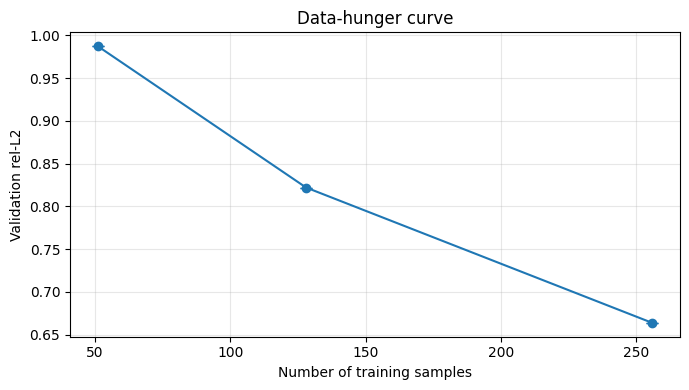

In [16]:
# =========================
# Data-hunger curve (subset size vs validation error)
# =========================
def train_eval_subset(train_files_subset, cfg, quick_epochs=3, seed=42):
    if len(train_files_subset) < cfg.get('min_subset_size', 1):
        raise RuntimeError(f'subset size {len(train_files_subset)} is below min_subset_size')

    set_seed(seed)

    ds = GridDataset(
        train_files_subset,
        grid_stride=cfg['train_grid_stride'],
    )
    drop_last = len(ds) >= cfg['batch_size']
    loader = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True, drop_last=drop_last)

    m = build_model(cfg)
    opt = torch.optim.AdamW(m.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=quick_epochs)
    loss_fn = LpLoss(d=3, p=2)

    for _ in range(quick_epochs):
        m.train()
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=NON_BLOCKING)
            y = y.to(DEVICE, non_blocking=NON_BLOCKING)
            opt.zero_grad(set_to_none=True)
            p = predict(m, x, expected_shape=y.shape)
            loss = loss_fn(p, y)
            loss.backward()
            opt.step()
        sch.step()

    vm = evaluate(m, VAL_LOADER)
    return vm['rel_l2']


def run_data_hunger_curve(fractions=(0.2, 0.5, 1.0), repeats=1, quick_epochs=3):
    rng = np.random.default_rng(CFG['seed'])
    n_total = len(TRAIN_FILES)
    curve = []

    for frac in fractions:
        n_use = max(1, int(frac * n_total))
        if n_use < CFG.get('min_subset_size', 1):
            print(f"[skip] frac={frac:.2f}: n={n_use} below min_subset_size={CFG.get('min_subset_size')} ")
            continue
        vals = []
        for r in range(repeats):
            idx = rng.choice(n_total, size=n_use, replace=False)
            subset = [TRAIN_FILES[i] for i in sorted(idx.tolist())]
            rel = train_eval_subset(subset, dict(CFG), quick_epochs=quick_epochs, seed=CFG['seed'] + r)
            vals.append(rel)
        curve.append((frac, n_use, float(np.mean(vals)), float(np.std(vals))))
        print(f"frac={frac:.2f}, n={n_use}, val rel-L2 mean={np.mean(vals):.4e}, std={np.std(vals):.2e}")

    ns = [c[1] for c in curve]
    means = [c[2] for c in curve]
    stds = [c[3] for c in curve]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.errorbar(ns, means, yerr=stds, marker='o', capsize=4)
    ax.set_xlabel('Number of training samples')
    ax.set_ylabel('Validation rel-L2')
    ax.set_title('Data-hunger curve')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_fig(fig, 'data_hunger_curve.png')
    plt.show()

    return curve


DATA_HUNGER = run_data_hunger_curve(fractions=(0.2, 0.5, 1.0), repeats=1, quick_epochs=3)


hidden_channels=32 -> val rel-L2 6.0119e-01
hidden_channels=48 -> val rel-L2 5.2167e-01
hidden_channels=64 -> val rel-L2 4.7712e-01
hidden_channels=96 -> val rel-L2 3.9837e-01
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_sweep_hidden_channels.png


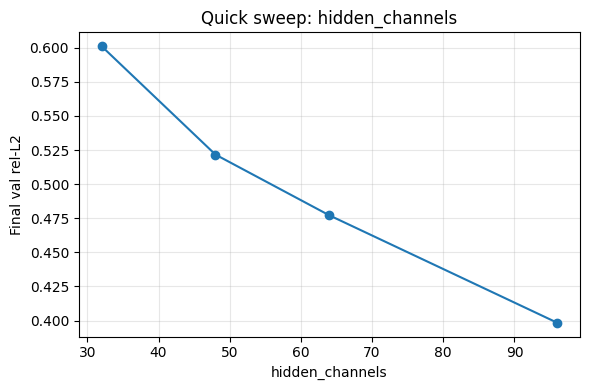

lr=0.0005 -> val rel-L2 5.9926e-01
lr=0.001 -> val rel-L2 4.7699e-01
lr=0.002 -> val rel-L2 3.8426e-01
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_sweep_lr.png


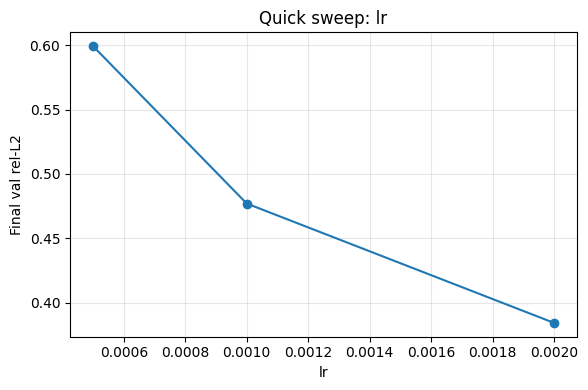

In [17]:
# =========================
# Convergence sensitivity sweeps
# =========================
def cfg_with(base_cfg, key, value):
    c = dict(base_cfg)
    c[key] = value
    return c


def quick_sweep(param_name, values, quick_epochs=6):
    results = []
    for v in values:
        c = cfg_with(CFG, param_name, v)
        rel = train_eval_subset(TRAIN_FILES, c, quick_epochs=quick_epochs)
        results.append((v, rel))
        print(f"{param_name}={v} -> val rel-L2 {rel:.4e}")

    xs = [r[0] for r in results]
    ys = [r[1] for r in results]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(xs, ys, marker='o')
    ax.set_xlabel(param_name)
    ax.set_ylabel('Final val rel-L2')
    ax.set_title(f'Quick sweep: {param_name}')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    save_fig(fig, f'sweep_{param_name}.png')
    plt.show()
    return results


SWEEP_HIDDEN = quick_sweep('hidden_channels', [32, 48, 64, 96], quick_epochs=6)
SWEEP_LR = quick_sweep('lr', [5e-4, 1e-3, 2e-3], quick_epochs=6)


Input key: input_grid_omega4
Input channel labels: ['omega', 'gamma_grid', 'sigma_grid', 'pos_density']
Output channel labels: ['Ux', 'Uy', 'Uz']
Raw pair shapes   -> x: (4, 32, 32, 32) y: (3, 32, 32, 32)
Loader pair shapes-> x: (4, 32, 32, 32) y: (3, 32, 32, 32)
3D grid size used by loader: (32, 32, 32)
Datapoints (voxels) per sample: 32768
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_data_profile_3d_pairs.png


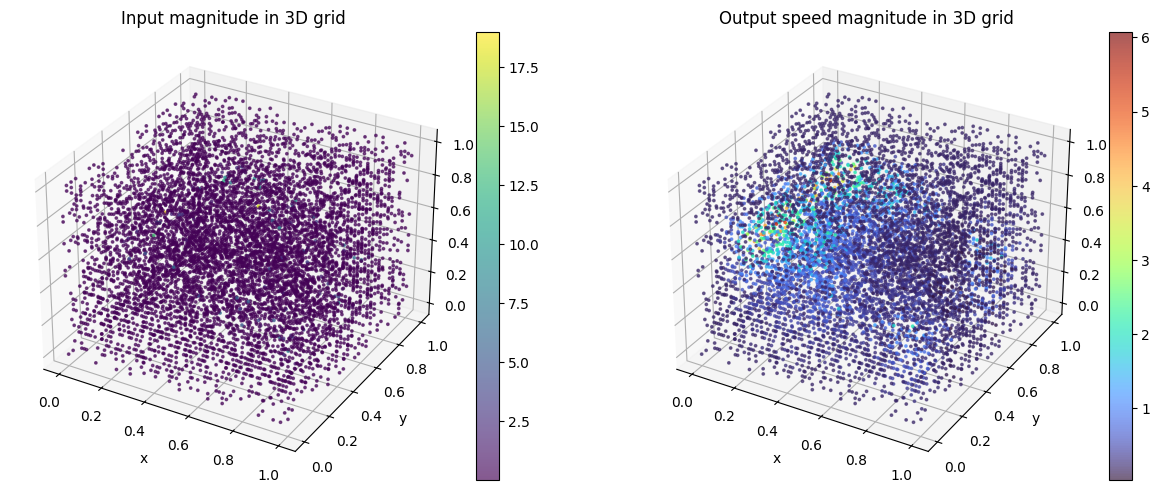

In [18]:
# =========================
# 3D Data Profile: pairs, channels, datapoints
# =========================
def fno_input_channel_labels(cfg):
    key = cfg['input_key']
    mapping = {
        'input_grid_omega': ['omega'],
        'input_grid_no_omega': ['gamma_grid', 'sigma_grid', 'pos_density'],
        'input_grid_omega4': ['omega', 'gamma_grid', 'sigma_grid', 'pos_density'],
    }
    labels = mapping.get(key, [f'ch_{i}' for i in range(cfg['input_channels'])])
    if len(labels) != cfg['input_channels']:
        labels = [f'ch_{i}' for i in range(cfg['input_channels'])]
    return labels

raw = np.load(TRAIN_FILES[0])
x_raw = np.asarray(raw[CFG['input_key']], dtype=np.float32)
y_raw = np.asarray(raw['U_grid'], dtype=np.float32)
x_ds, y_ds = TRAIN_DS[0]

labels = fno_input_channel_labels(CFG)
print('Input key:', CFG['input_key'])
print('Input channel labels:', labels)
print('Output channel labels:', ['Ux', 'Uy', 'Uz'])
print('Raw pair shapes   -> x:', tuple(x_raw.shape), 'y:', tuple(y_raw.shape))
print('Loader pair shapes-> x:', tuple(x_ds.shape), 'y:', tuple(y_ds.shape))
print('3D grid size used by loader:', tuple(x_ds.shape[1:]))
print('Datapoints (voxels) per sample:', int(np.prod(x_ds.shape[1:])))


def voxel_points_and_values(x_chw, y_chw, max_points=7000, seed=42):
    c, nx, ny, nz = x_chw.shape
    X, Y, Z = np.meshgrid(np.arange(nx), np.arange(ny), np.arange(nz), indexing='ij')
    pts = np.stack([X, Y, Z], axis=-1).reshape(-1, 3).astype(np.float32)
    denom = np.maximum(np.array([nx - 1, ny - 1, nz - 1], dtype=np.float32), 1.0)
    pts = pts / denom

    in_mag = np.linalg.norm(x_chw.reshape(c, -1), axis=0)
    out_speed = np.linalg.norm(y_chw.reshape(3, -1), axis=0)

    n = pts.shape[0]
    if n > max_points:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_points, replace=False)
        pts = pts[idx]
        in_mag = in_mag[idx]
        out_speed = out_speed[idx]

    return pts, in_mag, out_speed

pts, in_mag, out_speed = voxel_points_and_values(x_ds.numpy(), y_ds.numpy(), max_points=7000, seed=CFG['seed'])

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=in_mag, s=3, cmap='viridis', alpha=0.65)
ax1.set_title('Input magnitude in 3D grid')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
plt.colorbar(sc1, ax=ax1, fraction=0.04, pad=0.03)

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
sc2 = ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=out_speed, s=3, cmap='turbo', alpha=0.65)
ax2.set_title('Output speed magnitude in 3D grid')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
plt.colorbar(sc2, ax=ax2, fraction=0.04, pad=0.03)

fig.tight_layout()
save_fig(fig, 'data_profile_3d_pairs.png')
plt.show()


Flow: npz pair -> GridDataset(stride+normalization) -> DataLoader batch -> MODEL(x_norm) -> prediction_norm -> physical output
Demo TEST sample index: 0, folder=pair_3_fno_32, frame=720, file=frame_720_grid.npz
Batch input shape  [B,C,Nx,Ny,Nz]: (1, 4, 32, 32, 32)
Batch target shape [B,3,Nx,Ny,Nz]: (1, 3, 32, 32, 32)
Model output shape [B,3,Nx,Ny,Nz]: (1, 3, 32, 32, 32)
Input channels used: 4 from key: input_grid_omega4
Output channels predicted: ['Ux', 'Uy', 'Uz']
Active slice indices used: {'x': 16, 'y_candidates': [2, 15, 29], 'y_mid': 15, 'z': 13}
[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_io_flow_demo_orthogonal_projections.png


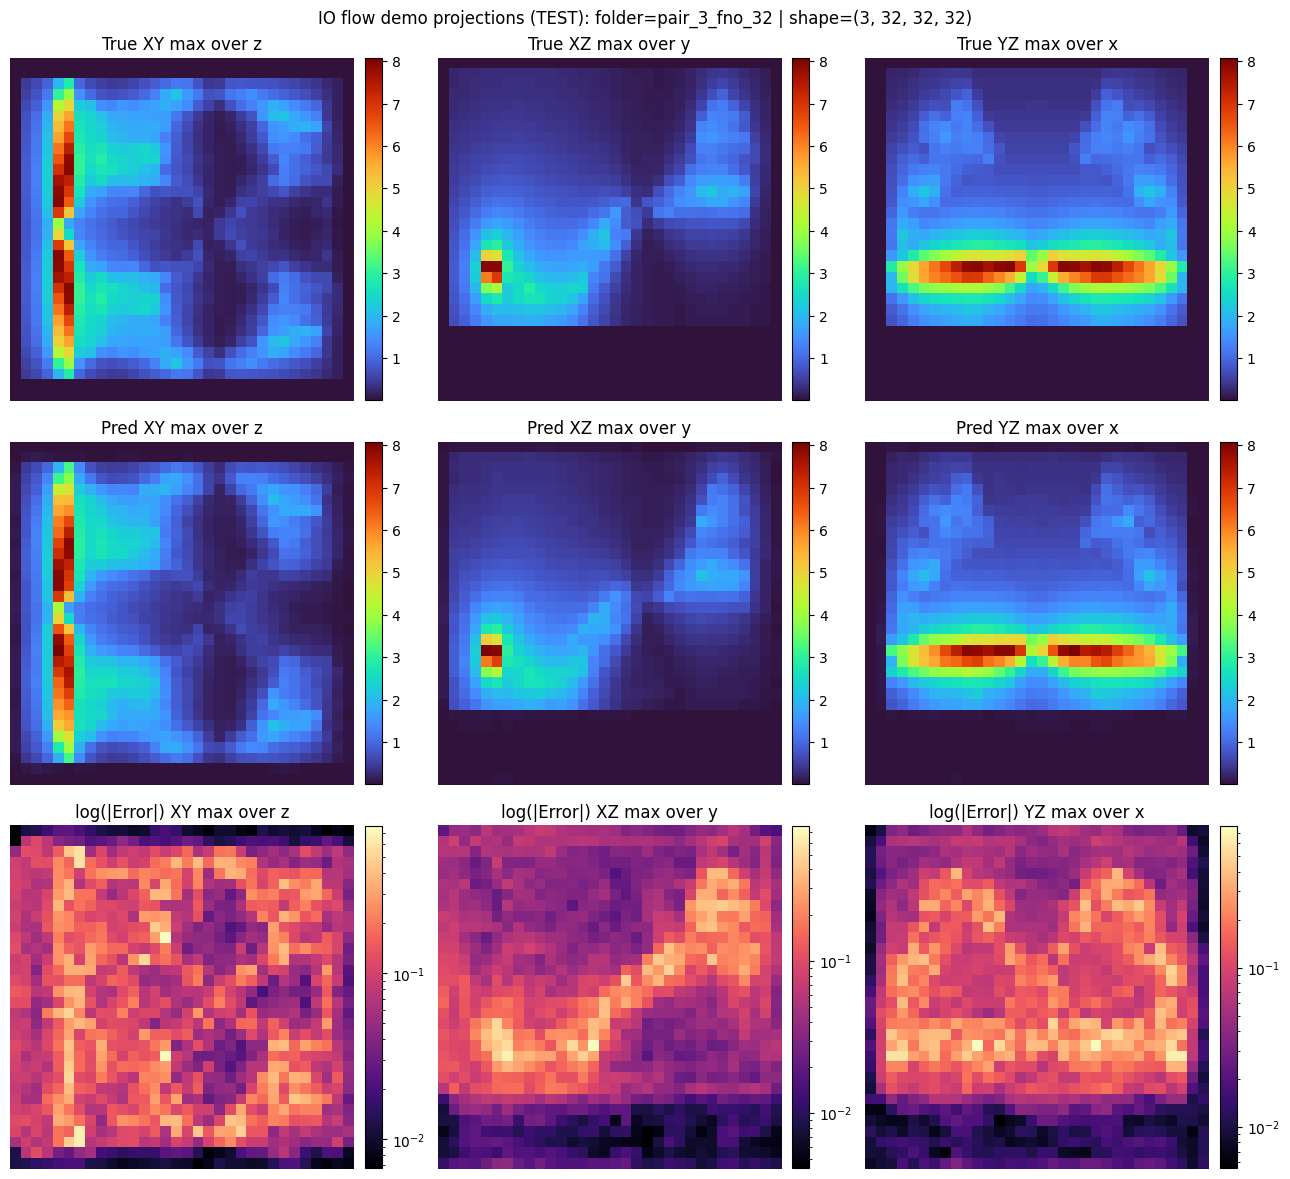

[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_io_flow_demo_orthogonal_slices.png


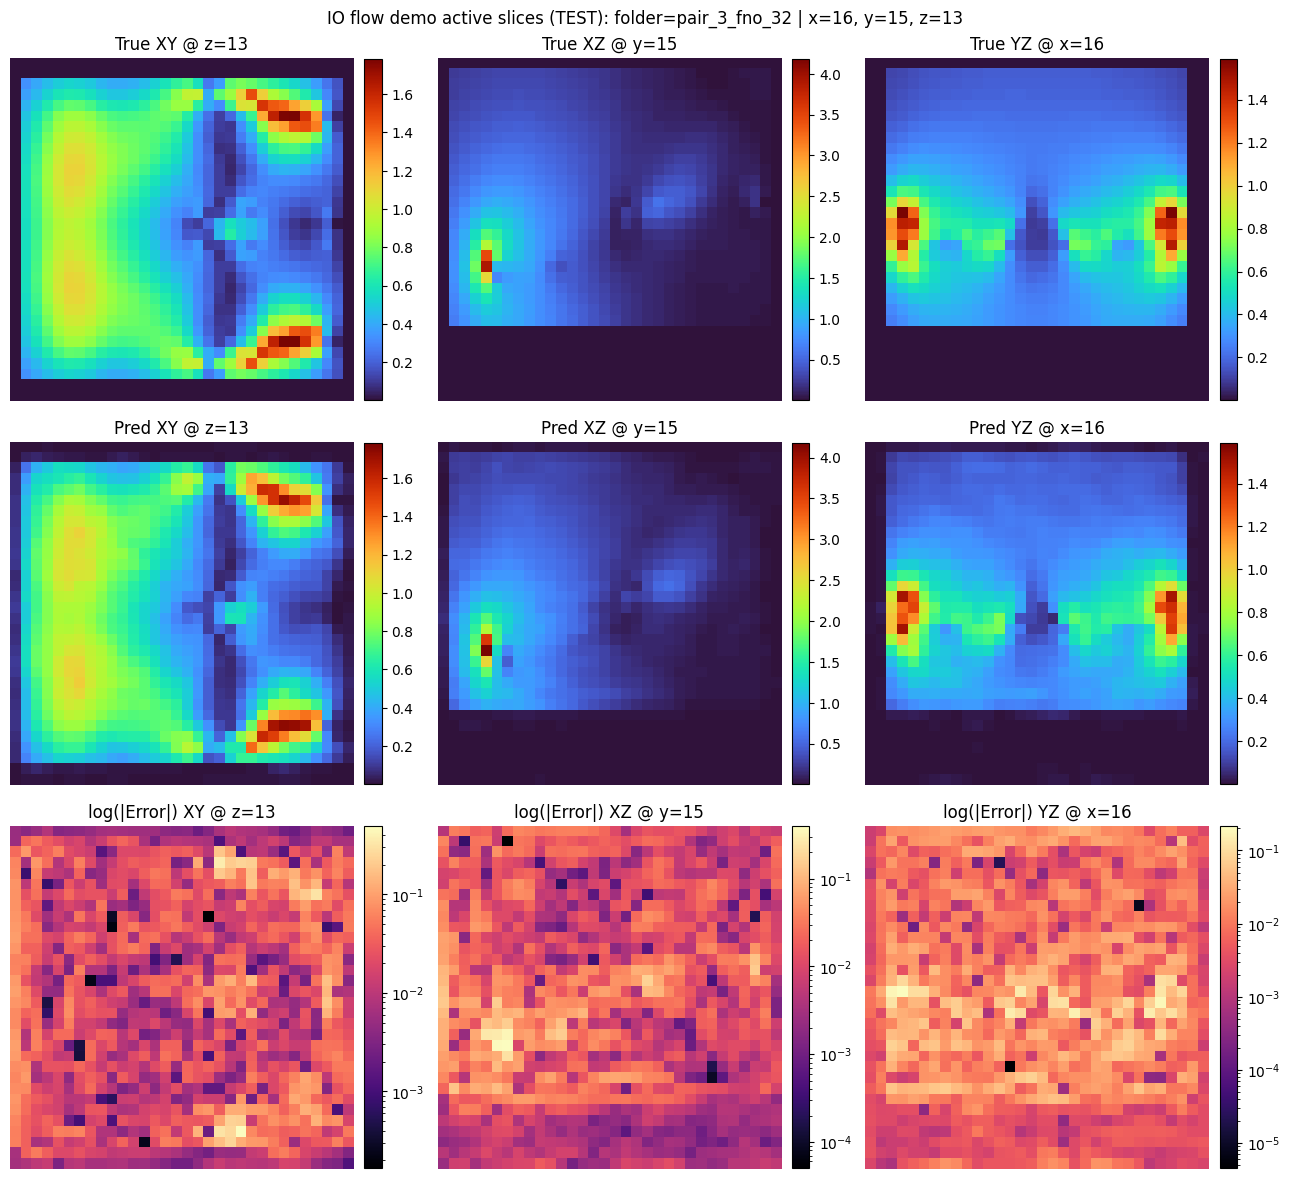

[saved] C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\results\fno_sr_randomdist_3d_io_flow_demo_3d_hotspots.png


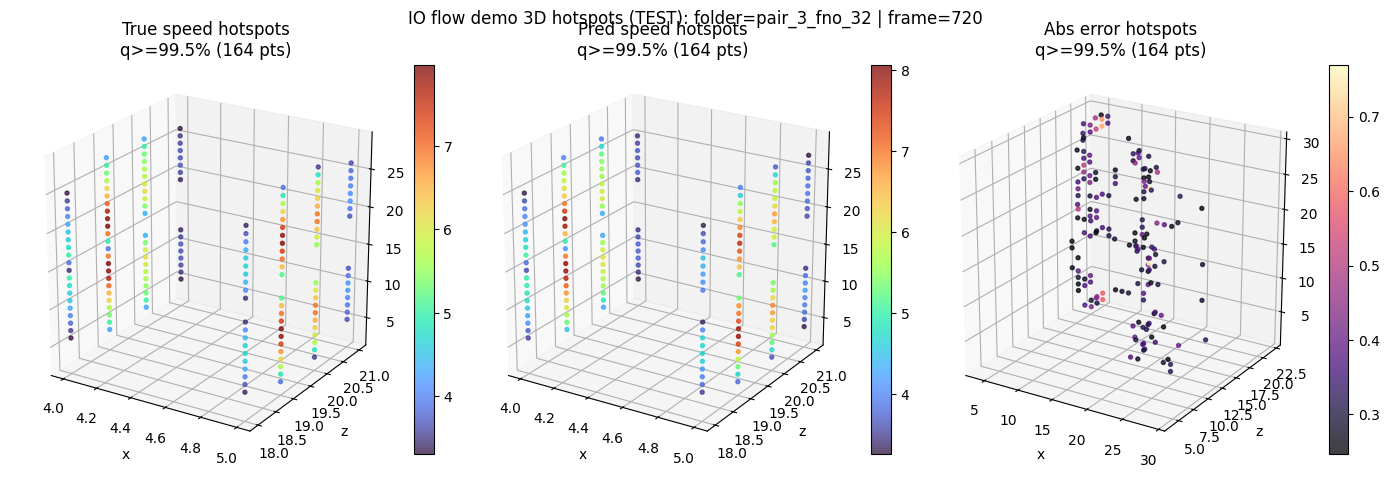

In [19]:
# =========================
# IO Flow Demo: NPZ -> tensor batch -> FNO -> prediction
# =========================
print('Flow: npz pair -> GridDataset(stride+normalization) -> DataLoader batch -> MODEL(x_norm) -> prediction_norm -> physical output')

if HAS_TEST:
    DEMO_FILES = TEST_FILES
    DEMO_DS = TEST_DS
    demo_label = 'TEST'
    demo_min_frame = CFG['min_frame_test']
else:
    DEMO_FILES = TRAIN_FILES
    DEMO_DS = TRAIN_DS
    demo_label = 'TRAIN'
    demo_min_frame = CFG['min_frame_trainval']

demo_idx = next((i for i, f in enumerate(DEMO_FILES) if parse_frame_id(f) >= demo_min_frame), 0)
demo_path = Path(DEMO_FILES[demo_idx])
print(f'Demo {demo_label} sample index: {demo_idx}, folder={demo_path.parent.name}, frame={parse_frame_id(demo_path)}, file={demo_path.name}')

x_norm, y_norm = DEMO_DS[demo_idx]
xb = x_norm.unsqueeze(0)
yb = y_norm.unsqueeze(0)
print('Batch input shape  [B,C,Nx,Ny,Nz]:', tuple(xb.shape))
print('Batch target shape [B,3,Nx,Ny,Nz]:', tuple(yb.shape))

with torch.no_grad():
    pred_norm_b = predict(MODEL, xb.to(DEVICE, non_blocking=NON_BLOCKING)).detach().cpu()

print('Model output shape [B,3,Nx,Ny,Nz]:', tuple(pred_norm_b.shape))
print('Input channels used:', CFG['input_channels'], 'from key:', CFG['input_key'])
print('Output channels predicted:', ['Ux', 'Uy', 'Uz'])

y_phys = to_physical_y(yb[0])
pred_phys = to_physical_y(pred_norm_b[0])
true_speed = speed_from_velocity(y_phys)
pred_speed = speed_from_velocity(pred_phys)
err_speed = np.abs(pred_speed - true_speed)
y_idx, y_energy = active_y_slice_indices(true_speed, n_slices=3, frac_threshold=0.05)

def safe_lognorm(arr):
    vmin = max(float(np.min(arr)), 1e-8)
    vmax = max(float(np.max(arr)), vmin * 10.0)
    return LogNorm(vmin=vmin, vmax=vmax)

def orthogonal_projections(vol):
    return {
        'XY max over z': np.max(vol, axis=2).T,
        'XZ max over y': np.max(vol, axis=1).T,
        'YZ max over x': np.max(vol, axis=0).T,
    }

def active_axis_index(vol, axis, frac_threshold=0.05):
    reduce_axes = tuple(i for i in range(vol.ndim) if i != axis)
    energy = np.sum(np.abs(vol), axis=reduce_axes)
    if float(np.max(energy)) <= 0.0:
        return vol.shape[axis] // 2
    active = np.where(energy >= frac_threshold * float(np.max(energy)))[0]
    if len(active) == 0:
        return int(np.argmax(energy))
    return int(active[len(active) // 2])

def orthogonal_slices(vol, x_idx, y_idx_sel, z_idx):
    return {
        f'XY @ z={z_idx}': vol[:, :, z_idx].T,
        f'XZ @ y={y_idx_sel}': vol[:, y_idx_sel, :].T,
        f'YZ @ x={x_idx}': vol[x_idx, :, :].T,
    }

def top_voxel_coords(vol, q=0.995, max_points=3000):
    thr = float(np.quantile(vol, q))
    coords = np.argwhere(vol >= thr)
    if len(coords) == 0:
        flat_idx = int(np.argmax(vol))
        coords = np.array([np.unravel_index(flat_idx, vol.shape)])
    if len(coords) > max_points:
        step = max(1, len(coords) // max_points)
        coords = coords[::step][:max_points]
    vals = vol[coords[:, 0], coords[:, 1], coords[:, 2]]
    return coords, vals, thr

x_idx = active_axis_index(true_speed, axis=0)
y_sel = y_idx[len(y_idx) // 2]
z_idx = active_axis_index(true_speed, axis=2)
print('Active slice indices used:', {'x': x_idx, 'y_candidates': y_idx, 'y_mid': y_sel, 'z': z_idx})

proj_true = orthogonal_projections(true_speed)
proj_pred = orthogonal_projections(pred_speed)
proj_err = orthogonal_projections(err_speed)
slice_true = orthogonal_slices(true_speed, x_idx=x_idx, y_idx_sel=y_sel, z_idx=z_idx)
slice_pred = orthogonal_slices(pred_speed, x_idx=x_idx, y_idx_sel=y_sel, z_idx=z_idx)
slice_err = orthogonal_slices(err_speed, x_idx=x_idx, y_idx_sel=y_sel, z_idx=z_idx)

fig_proj, axs = plt.subplots(3, 3, figsize=(13, 12))
for col, name in enumerate(proj_true.keys()):
    t_view = proj_true[name]
    p_view = proj_pred[name]
    e_view = proj_err[name]
    vmin = min(float(np.min(t_view)), float(np.min(p_view)))
    vmax = max(float(np.max(t_view)), float(np.max(p_view)))

    im_t = axs[0, col].imshow(t_view, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[0, col].set_title(f'True {name}')
    axs[0, col].axis('off')
    plt.colorbar(im_t, ax=axs[0, col], fraction=0.046, pad=0.03)

    im_p = axs[1, col].imshow(p_view, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[1, col].set_title(f'Pred {name}')
    axs[1, col].axis('off')
    plt.colorbar(im_p, ax=axs[1, col], fraction=0.046, pad=0.03)

    im_e = axs[2, col].imshow(e_view, cmap='magma', norm=safe_lognorm(e_view))
    axs[2, col].set_title(f'log(|Error|) {name}')
    axs[2, col].axis('off')
    plt.colorbar(im_e, ax=axs[2, col], fraction=0.046, pad=0.03)

fig_proj.suptitle(
    f'IO flow demo projections ({demo_label}): folder={demo_path.parent.name} | shape={tuple(y_phys.shape)}',
    fontsize=12,
)
fig_proj.tight_layout()
save_fig(fig_proj, 'io_flow_demo_orthogonal_projections.png')
plt.show()

fig_slice, axs = plt.subplots(3, 3, figsize=(13, 12))
for col, name in enumerate(slice_true.keys()):
    t_view = slice_true[name]
    p_view = slice_pred[name]
    e_view = slice_err[name]
    vmin = min(float(np.min(t_view)), float(np.min(p_view)))
    vmax = max(float(np.max(t_view)), float(np.max(p_view)))

    im_t = axs[0, col].imshow(t_view, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[0, col].set_title(f'True {name}')
    axs[0, col].axis('off')
    plt.colorbar(im_t, ax=axs[0, col], fraction=0.046, pad=0.03)

    im_p = axs[1, col].imshow(p_view, cmap='turbo', vmin=vmin, vmax=vmax)
    axs[1, col].set_title(f'Pred {name}')
    axs[1, col].axis('off')
    plt.colorbar(im_p, ax=axs[1, col], fraction=0.046, pad=0.03)

    im_e = axs[2, col].imshow(e_view, cmap='magma', norm=safe_lognorm(e_view))
    axs[2, col].set_title(f'log(|Error|) {name}')
    axs[2, col].axis('off')
    plt.colorbar(im_e, ax=axs[2, col], fraction=0.046, pad=0.03)

fig_slice.suptitle(
    f'IO flow demo active slices ({demo_label}): folder={demo_path.parent.name} | x={x_idx}, y={y_sel}, z={z_idx}',
    fontsize=12,
)
fig_slice.tight_layout()
save_fig(fig_slice, 'io_flow_demo_orthogonal_slices.png')
plt.show()

fig_3d = plt.figure(figsize=(14, 4.8))
volumes_3d = [
    ('True speed hotspots', true_speed, 'turbo'),
    ('Pred speed hotspots', pred_speed, 'turbo'),
    ('Abs error hotspots', err_speed, 'magma'),
]
for i, (title, vol, cmap) in enumerate(volumes_3d, start=1):
    ax = fig_3d.add_subplot(1, 3, i, projection='3d')
    coords, vals, thr = top_voxel_coords(vol, q=0.995, max_points=2500)
    sc = ax.scatter(coords[:, 0], coords[:, 2], coords[:, 1], c=vals, s=8, cmap=cmap, alpha=0.75)
    ax.set_title(f'{title}\nq>=99.5% ({len(coords)} pts)')
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_zlabel('y')
    ax.view_init(elev=22, azim=-58)
    ax.set_box_aspect((true_speed.shape[0], true_speed.shape[2], true_speed.shape[1]))
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)

fig_3d.suptitle(
    f'IO flow demo 3D hotspots ({demo_label}): folder={demo_path.parent.name} | frame={parse_frame_id(demo_path)}',
    fontsize=12,
)
fig_3d.tight_layout()
save_fig(fig_3d, 'io_flow_demo_3d_hotspots.png')
plt.show()
